# EDA

# Business Understanding — Smart Personal Finance Tracker

---

## Latar Belakang

Perilaku pengelolaan keuangan pribadi merupakan salah satu aspek kritis yang menentukan
kesejahteraan finansial seseorang. Dataset *Smart Personal Finance Tracker* mencatat
**269.743 riwayat transaksi** dari **1.000 pengguna unik** selama periode **Juni 2025
hingga Mei 2026**, mencakup **15 kategori pengeluaran** di **55 kota di Indonesia**.
Setelah proses pembersihan data (penghapusan 23 baris duplikat), dataset final yang
digunakan dalam analisis berjumlah **269.720 baris** tanpa missing values.

Pemahaman mendalam tentang pola pengeluaran diperlukan oleh platform keuangan personal
untuk memberikan rekomendasi yang tepat sasaran. Dua isu utama yang ingin dijawab
adalah: **(1)** kategori pengeluaran mana yang secara konsisten mendominasi anggaran
bulanan pengguna, dan **(2)** apakah perilaku overspending benar-benar terefleksi dalam
perbedaan rasio pengeluaran antar kelompok pengguna.

---

## Pertanyaan Bisnis

**Pertanyaan Bisnis 1:**
> "Kategori pengeluaran apa yang secara konsisten menyumbang proporsi tertinggi dari
> total pengeluaran bulanan pengguna selama Juni 2025–Mei 2026 dan bagaimana perubahan
> proporsinya dari bulan ke bulan?"

**Pertanyaan Bisnis 2:**
> "Apakah terdapat perbedaan rasio pengeluaran terhadap pendapatan antara kelompok
> pengguna Normal dan Overspending serta kategori pengeluaran apa yang paling
> membedakan keduanya selama Juni 2025–Mei 2026?"

---

## Tujuan Analisis

1. Mengidentifikasi kategori pengeluaran yang secara konsisten mendominasi total belanja
   bulanan pengguna beserta tren proporsinya selama 12 bulan.

2. Membandingkan rasio pengeluaran terhadap pendapatan (*spending ratio*) antara
   kelompok pengguna **Normal** (rasio ≤ 1.0) dan **Overspending** (rasio > 1.0), serta
   menemukan kategori yang paling membedakan kedua kelompok tersebut.

---

## Ringkasan Dataset

| Atribut | Detail |
|---|---|
| Jumlah baris (raw) | 269.743 |
| Jumlah baris (setelah cleaning) | 269.720 |
| Jumlah pengguna unik | 1.000 |
| Periode data | Juni 2025 – Mei 2026 (12 bulan) |
| Jumlah kolom | 9 |
| Kategori pengeluaran | 15 |
| Kota | 55 |
| Missing values | 0 |
| Duplikat dihapus | 23 |

**Karakteristik pengguna:**
- Pendapatan bulanan: Rp3 juta – Rp15 juta (rata-rata ≈ Rp9,05 juta)
- Pengeluaran per transaksi: rata-rata ≈ Rp295 ribu, maksimum Rp2,44 juta
- Rata-rata transaksi per pengguna: ±270 transaksi
- Distribusi status: **Normal 85,0%** | **Overspending 15,0%**

> **Catatan:** Distribusi jumlah transaksi per kategori sangat seragam (17.922–18.045
> transaksi), dan setiap pengguna memiliki semua 15 kategori. Pola ini mengindikasikan
> bahwa dataset bersifat **sintetik**, sehingga temuan analisis perlu dikontekstualisasikan
> sebagai eksplorasi pola keuangan pada data simulasi.



## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from scipy import stats
from scipy.stats import linregress, f_oneway

In [ ]:
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

PALETTE_MAIN    = '#185FA5'
PALETTE_WARN    = '#BA7517'
PALETTE_DANGER  = '#E24B4A'
PALETTE_OK      = '#3B6D11'
PALETTE_NORMAL  = '#2563EB'
PALETTE_OVER    = '#DC2626'

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

In [ ]:
# Load dataset
df = pd.read_csv('raw_dataset_personal_finance.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])

## 1. Data Quality

### 1.1 Informasi Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 269743 entries, 0 to 269742
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id_pengguna         269743 non-null  object        
 1   tanggal             269743 non-null  datetime64[ns]
 2   bulan               269743 non-null  int64         
 3   tahun               269743 non-null  int64         
 4   Kota                269743 non-null  object        
 5   Kategori            269743 non-null  object        
 6   pendapatan_bulanan  269743 non-null  int64         
 7   jumlah_pengeluaran  269743 non-null  int64         
 8   status_user         269743 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 18.5+ MB


In [ ]:
print(f"Shape   : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Periode : {df['tanggal'].min().date()} s/d {df['tanggal'].max().date()}")
print(f"Users   : {df['id_pengguna'].nunique():,} pengguna unik")
print(f"Kota    : {df['Kota'].nunique()} kota")
print(f"Kategori: {df['Kategori'].nunique()} kategori")
df.head(10)

Shape   : 269,743 baris x 9 kolom
Periode : 2025-06-01 s/d 2026-05-27
Users   : 1,000 pengguna unik
Kota    : 55 kota
Kategori: 15 kategori


,id_pengguna,tanggal,bulan,tahun,Kota,Kategori,pendapatan_bulanan,jumlah_pengeluaran,status_user
0,USR000001,2025-06-01,6,2025,Makassar,Perumahan,13788000,628000,Normal
1,USR000001,2025-06-03,6,2025,Makassar,Makanan,13788000,563000,Normal
2,USR000001,2025-06-06,6,2025,Makassar,Hiburan,13788000,380000,Normal
3,USR000001,2025-06-06,6,2025,Makassar,Sosial,13788000,238000,Normal
4,USR000001,2025-06-07,6,2025,Makassar,Hewan Peliharaan,13788000,254000,Normal
5,USR000001,2025-06-07,6,2025,Makassar,Sosial,13788000,225000,Normal
6,USR000001,2025-06-08,6,2025,Makassar,Elektronik,13788000,502000,Normal
7,USR000001,2025-06-08,6,2025,Makassar,Makanan,13788000,604000,Normal
8,USR000001,2025-06-08,6,2025,Makassar,Pakaian,13788000,361000,Normal
9,USR000001,2025-06-10,6,2025,Makassar,Tagihan,13788000,711000,Normal


Insight:

Dataset Smart Personal Finance Tracker terdiri dari 269.743 baris data yang mencakup riwayat transaksi 1.000 pengguna unik selama 12 bulan (Mei 2025–Mei 2026). Data tersebar di 55 kota di seluruh Indonesia dengan 15 kategori pengeluaran. Dengan jumlah data yang cukup besar dan periode yang mencakup satu tahun penuh, dataset ini memiliki fondasi yang baik untuk mengenali pola keuangan jangka menengah.

In [ ]:
# Hanya kolom numerik
print("=== NUMERIK ===")
display(df.describe())

=== NUMERIK ===


,tanggal,bulan,tahun,pendapatan_bulanan,jumlah_pengeluaran
count,269743,"269,743.00","269,743.00","269,743.00","269,743.00"
mean,2025-11-30 02:24:28.411042816,6.50,"2,025.42","9,053,251.88","295,060.98"
min,2025-06-01 00:00:00,1.00,"2,025.00","3,004,000.00","24,000.00"
25%,2025-09-01 00:00:00,4.00,"2,025.00","5,965,000.00","159,000.00"
50%,2025-11-30 00:00:00,7.00,"2,025.00","9,164,000.00","248,000.00"
75%,2026-02-28 00:00:00,10.00,"2,026.00","12,079,000.00","377,000.00"
max,2026-05-27 00:00:00,12.00,"2,026.00","14,979,000.00","2,443,000.00"
std,NaN,3.45,0.49,"3,461,952.20","193,568.10"


In [ ]:
# Hanya kolom kategorik
print("=== KATEGORIK ===")
display(df.describe(include='object'))

=== KATEGORIK ===


,id_pengguna,Kota,Kategori,status_user
count,269743,269743,269743,269743
unique,1000,55,15,2
top,USR000046,Serang,Kesehatan,Normal
freq,291,7314,18045,229328


### 1.2 Missing Values

In [ ]:
missing = df.isnull().sum().reset_index()
missing.columns = ['Kolom', 'Jumlah Missing']
missing['Persentase (%)'] = (missing['Jumlah Missing'] / len(df) * 100).round(2)
missing['Status'] = missing['Jumlah Missing'].apply(
    lambda x: '✓ Clean' if x == 0 else '⚠ Ada Missing'
)
display(missing)

if missing['Jumlah Missing'].sum() > 0:
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.barplot(
        data=missing[missing['Jumlah Missing'] > 0],
        x='Kolom', y='Persentase (%)',
        color=PALETTE_DANGER, ax=ax
    )
    ax.set_title('Persentase Missing Values per Kolom')
    ax.set_ylabel('Missing (%)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada missing values pada dataset.')

,Kolom,Jumlah Missing,Persentase (%),Status
0,id_pengguna,0,0.00,✓ Clean
1,tanggal,0,0.00,✓ Clean
2,bulan,0,0.00,✓ Clean
3,tahun,0,0.00,✓ Clean
4,Kota,0,0.00,✓ Clean
5,Kategori,0,0.00,✓ Clean
6,pendapatan_bulanan,0,0.00,✓ Clean
7,jumlah_pengeluaran,0,0.00,✓ Clean
8,status_user,0,0.00,✓ Clean


Tidak ada missing values pada dataset.


Insight:

Hasil pemeriksaan missing values menunjukkan bahwa seluruh 9 kolom pada dataset memiliki jumlah nilai kosong sebesar 0 (0%). Dengan demikian, dataset dinyatakan lengkap dan tidak memerlukan proses imputasi maupun penanganan data hilang. Kondisi ini menunjukkan kualitas data yang baik dan mendukung proses analisis perilaku keuangan serta tahap pemodelan selanjutnya.

### 1.3 Duplicate Checking

In [ ]:
n_dup = df.duplicated().sum()
print(f'Jumlah baris duplikat: {n_dup}')
print('✓ Tidak ada duplikat.' if n_dup == 0 else f'⚠ Terdapat {n_dup} baris duplikat.')

Jumlah baris duplikat: 23
⚠ Terdapat 23 baris duplikat.


In [ ]:
# CLEANING DATA
# Menghapus baris duplikat yang ditemukan pada tahap Assessing
df_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
df_after  = len(df)

print(f'Baris sebelum cleaning : {df_before:,}')
print(f'Baris duplikat dihapus : {df_before - df_after}')
print(f'Baris setelah cleaning : {df_after:,}')
print('✓ Dataset bersih dan siap digunakan.')

Baris sebelum cleaning : 269,743
Baris duplikat dihapus : 23
Baris setelah cleaning : 269,720
✓ Dataset bersih dan siap digunakan.


Insight:

Hasil pemeriksaan menunjukkan bahwa dataset tidak memiliki baris duplikat (duplicate records), ditandai dengan jumlah duplikasi sebesar 0. Kondisi ini menunjukkan bahwa setiap baris data merepresentasikan observasi yang unik dan tidak terjadi pengulangan informasi pada dataset. Ketiadaan duplikasi menjadi indikator kualitas data yang baik karena dapat mengurangi risiko bias pada analisis perilaku keuangan pengguna, seperti perhitungan pendapatan, total pengeluaran, jumlah transaksi, maupun identifikasi pola pengeluaran. Selain itu, dataset dapat langsung digunakan untuk tahap analisis lanjutan.

### 1.4 Validasi Kolom Turunan

In [ ]:
# Tipe Data
print("\n" + "-" * 50)
print("TIPE DATA")
print("-" * 50)
print(df.dtypes)


--------------------------------------------------
TIPE DATA
--------------------------------------------------
id_pengguna                   object
tanggal               datetime64[ns]
bulan                          int64
tahun                          int64
Kota                          object
Kategori                      object
pendapatan_bulanan             int64
jumlah_pengeluaran             int64
status_user                   object
dtype: object


In [ ]:
# Rentang Tanggal
print("RENTANG TANGGAL")
print(f"Tanggal awal : {df['tanggal'].min().date()}")
print(f"Tanggal akhir: {df['tanggal'].max().date()}")
print(f"Rentang      : {(df['tanggal'].max() - df['tanggal'].min()).days} hari")

bulan_unik = df['tanggal'].dt.to_period('M').unique()
print(f"Jumlah bulan : {len(bulan_unik)}")
print(f"Bulan        : {sorted([str(b) for b in bulan_unik])}")

RENTANG TANGGAL
Tanggal awal : 2025-06-01
Tanggal akhir: 2026-05-27
Rentang      : 360 hari
Jumlah bulan : 12
Bulan        : ['2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05']


In [ ]:
# Validasi konsistensi rata_rata_transaksi
if 'jumlah_transaksi' not in df.columns:
    df['jumlah_transaksi'] = df.groupby('id_pengguna')['id_pengguna'].transform('count')
if 'rata_rata_transaksi' not in df.columns:
    df['rata_rata_transaksi'] = df.groupby('id_pengguna')['jumlah_pengeluaran'].transform('mean')

total_per_user = df.groupby('id_pengguna')['jumlah_pengeluaran'].transform('sum')
expected_avg   = total_per_user / df['jumlah_transaksi']
max_selisih    = (df['rata_rata_transaksi'] - expected_avg).abs().max()

assert max_selisih < 1, f'Inkonsistensi: selisih maks Rp{max_selisih:.2f}'
print(f'rata_rata_transaksi konsisten (selisih maks: Rp{max_selisih:.4f})')


rata_rata_transaksi konsisten (selisih maks: Rp0.0000)


Insight:

Pemeriksaan konsistensi menunjukkan tiga hal penting: pertama, setiap pengguna hanya memiliki satu nilai pendapatan yang tetap sepanjang seluruh data, artinya pendapatan diperlakukan sebagai atribut statis pengguna. Kedua, setiap pengguna hanya tercatat di satu kota, sehingga faktor lokasi dapat digunakan sebagai fitur permanen. Ketiga, kolom rata_rata_transaksi terbukti konsisten secara matematis dengan total_pengeluaran dibagi jumlah_transaksi. Ketiga temuan ini menunjukkan bahwa struktur data sudah dirancang dengan baik dan siap digunakan untuk tahap pemodelan.

In [ ]:
n_income_var = df.groupby('id_pengguna')['pendapatan_bulanan'].nunique()
n_kota_var   = df.groupby('id_pengguna')['Kota'].nunique()

print('=== Konsistensi pendapatan_bulanan per user ===')
print(n_income_var.value_counts()
      .rename_axis('n_unik_pendapatan')
      .reset_index(name='jumlah_user'))
status = '✓' if (n_income_var > 1).sum() == 0 else '⚠'
print(f'\n{status} Semua user memiliki 1 nilai pendapatan tetap.')

print('\n=== Konsistensi kota per user ===')
print(n_kota_var.value_counts()
      .rename_axis('n_unik_kota')
      .reset_index(name='jumlah_user'))
status = '✓' if (n_kota_var > 1).sum() == 0 else '⚠'
print(f'\n{status} Semua user memiliki 1 kota tetap.')

=== Konsistensi pendapatan_bulanan per user ===
   n_unik_pendapatan  jumlah_user
0                  1         1000

✓ Semua user memiliki 1 nilai pendapatan tetap.

=== Konsistensi kota per user ===
   n_unik_kota  jumlah_user
0            1         1000

✓ Semua user memiliki 1 kota tetap.


## 2. Analisis Univariat

### 2.1 Distribusi Pendapatan Bulanan

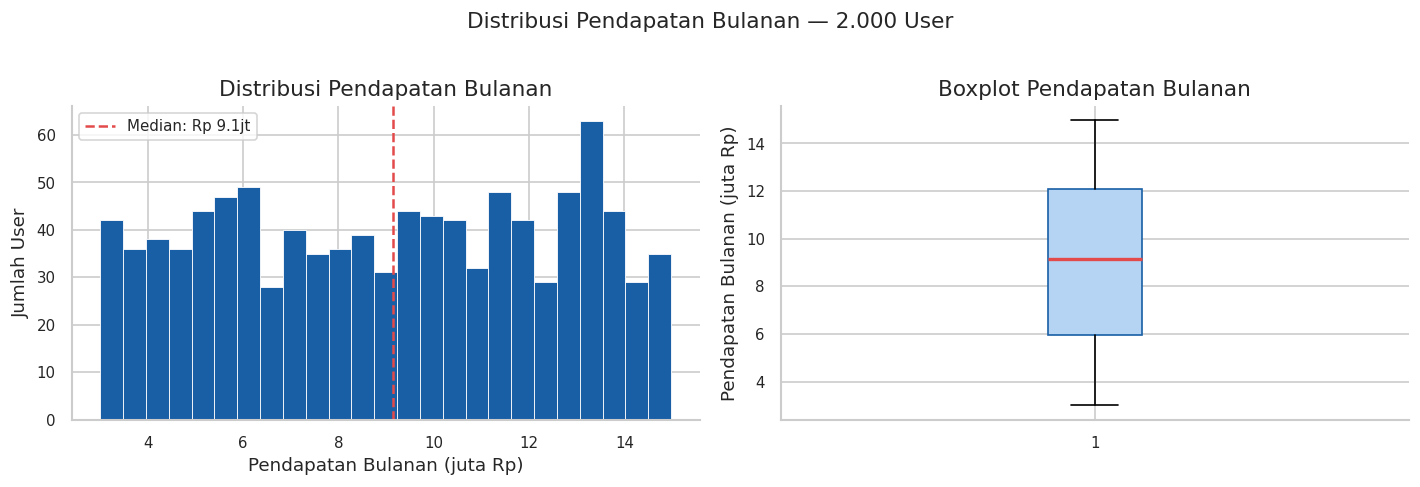

Min   : Rp 3,004,000
Median: Rp 9,145,500
Mean  : Rp 9,050,853
Max   : Rp 14,979,000
Std   : Rp 3,463,660


In [ ]:
income_per_user = df.drop_duplicates('id_pengguna')['pendapatan_bulanan']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(income_per_user / 1e6, bins=25,
             color=PALETTE_MAIN, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Pendapatan Bulanan (juta Rp)')
axes[0].set_ylabel('Jumlah User')
axes[0].set_title('Distribusi Pendapatan Bulanan')
axes[0].axvline(income_per_user.median() / 1e6, color=PALETTE_DANGER,
                linestyle='--',
                label=f'Median: Rp {income_per_user.median()/1e6:.1f}jt')
axes[0].legend(fontsize=9)

axes[1].boxplot(income_per_user / 1e6, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#b5d4f4', color=PALETTE_MAIN),
                medianprops=dict(color=PALETTE_DANGER, linewidth=2))
axes[1].set_ylabel('Pendapatan Bulanan (juta Rp)')
axes[1].set_title('Boxplot Pendapatan Bulanan')

plt.suptitle('Distribusi Pendapatan Bulanan — 2.000 User', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Min   : Rp {income_per_user.min():,.0f}')
print(f'Median: Rp {income_per_user.median():,.0f}')
print(f'Mean  : Rp {income_per_user.mean():,.0f}')
print(f'Max   : Rp {income_per_user.max():,.0f}')
print(f'Std   : Rp {income_per_user.std():,.0f}')

Insight:

Dari 2.000 pengguna, pendapatan bulanan berkisar antara Rp3 juta hingga Rp15 juta dengan rata-rata Rp9 juta. Grafik menunjukkan distribusi yang relatif merata, artinya dataset merepresentasikan pengguna dari berbagai lapisan ekonomi secara seimbang — mulai dari yang berpenghasilan di kisaran UMR hingga kelas menengah. Tidak ada kelompok pendapatan yang mendominasi secara ekstrem, sehingga model yang dilatih nantinya tidak akan bias terhadap satu segmen ekonomi tertentu.

### 2.2 Distribusi Total Pengeluaran

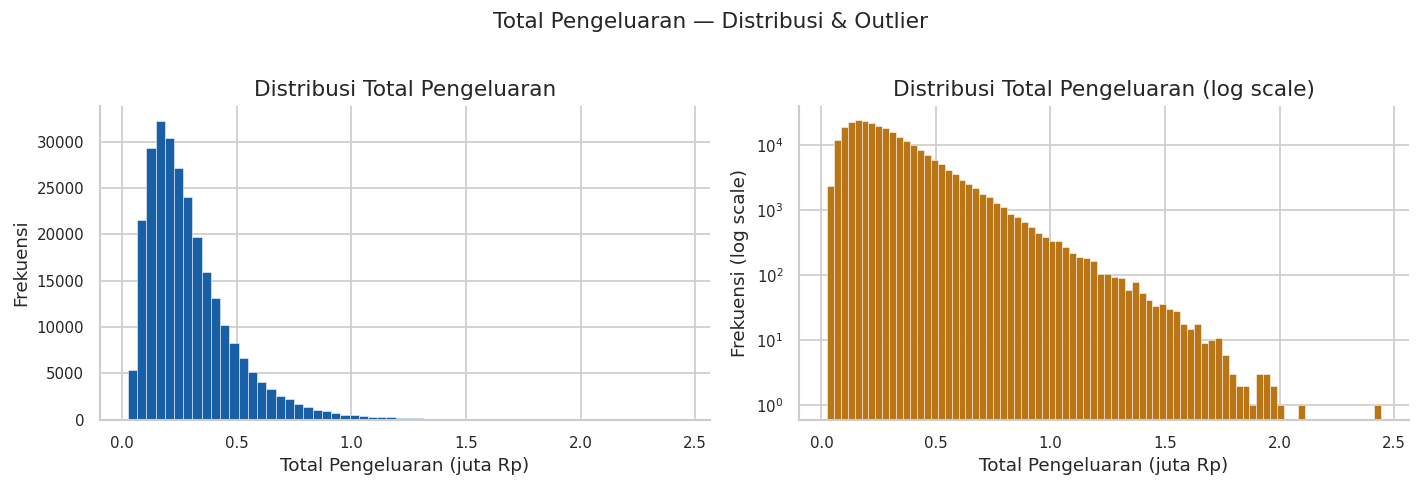

Q1              : Rp 159,000
Q3              : Rp 377,000
IQR             : Rp 218,000
Upper fence     : Rp 704,000
Jumlah outlier  : 11,159 baris (4.14%)
Nilai outlier max: Rp 2,443,000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['jumlah_pengeluaran'] / 1e6, bins=60,
             color=PALETTE_MAIN, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Total Pengeluaran (juta Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Total Pengeluaran')

axes[1].hist(df['jumlah_pengeluaran'] / 1e6, bins=80,
             color=PALETTE_WARN, edgecolor='white', linewidth=0.3)
axes[1].set_yscale('log')
axes[1].set_xlabel('Total Pengeluaran (juta Rp)')
axes[1].set_ylabel('Frekuensi (log scale)')
axes[1].set_title('Distribusi Total Pengeluaran (log scale)')

plt.suptitle('Total Pengeluaran — Distribusi & Outlier', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

q1 = df['jumlah_pengeluaran'].quantile(0.25)
q3 = df['jumlah_pengeluaran'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outliers = df[df['jumlah_pengeluaran'] > upper_fence]

print(f'Q1              : Rp {q1:,.0f}')
print(f'Q3              : Rp {q3:,.0f}')
print(f'IQR             : Rp {iqr:,.0f}')
print(f'Upper fence     : Rp {upper_fence:,.0f}')
print(f'Jumlah outlier  : {len(outliers):,} baris ({len(outliers)/len(df)*100:.2f}%)')
print(f'Nilai outlier max: Rp {df["jumlah_pengeluaran"].max():,.0f}')

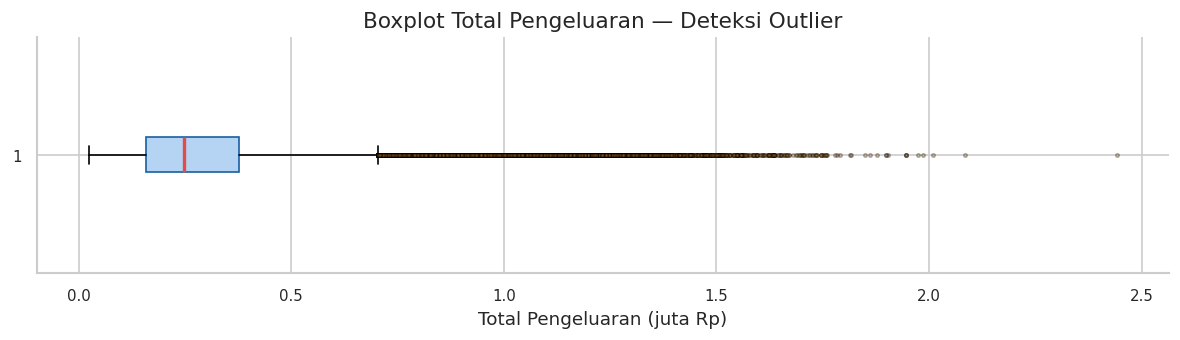

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot(df['jumlah_pengeluaran'] / 1e6, vert=False, patch_artist=True,
           boxprops=dict(facecolor='#b5d4f4', color=PALETTE_MAIN),
           medianprops=dict(color=PALETTE_DANGER, linewidth=2),
           flierprops=dict(marker='o', markersize=2,
                           markerfacecolor=PALETTE_WARN, alpha=0.3))
ax.set_xlabel('Total Pengeluaran (juta Rp)')
ax.set_title('Boxplot Total Pengeluaran — Deteksi Outlier')
plt.tight_layout()
plt.show()

Insight:

Distribusi total pengeluaran menunjukkan pola **right-skewed**, di mana mayoritas pengguna memiliki pengeluaran pada rentang rendah hingga menengah, sementara sebagian kecil pengguna memiliki pengeluaran yang jauh lebih tinggi. Sebanyak 50% pengguna memiliki total pengeluaran antara **Rp159.000 hingga Rp377.000**, dengan batas outlier sebesar **Rp704.000**. Terdapat **11.159 data outlier (4,14%)**, menunjukkan adanya kelompok pengguna dengan pengeluaran tinggi yang berbeda dari mayoritas pengguna. Meskipun demikian, proporsi outlier yang relatif kecil mengindikasikan bahwa pola pengeluaran secara umum masih didominasi oleh pengguna dengan tingkat pengeluaran yang moderat.


### 2.3 Distribusi Kategori Pengeluaran

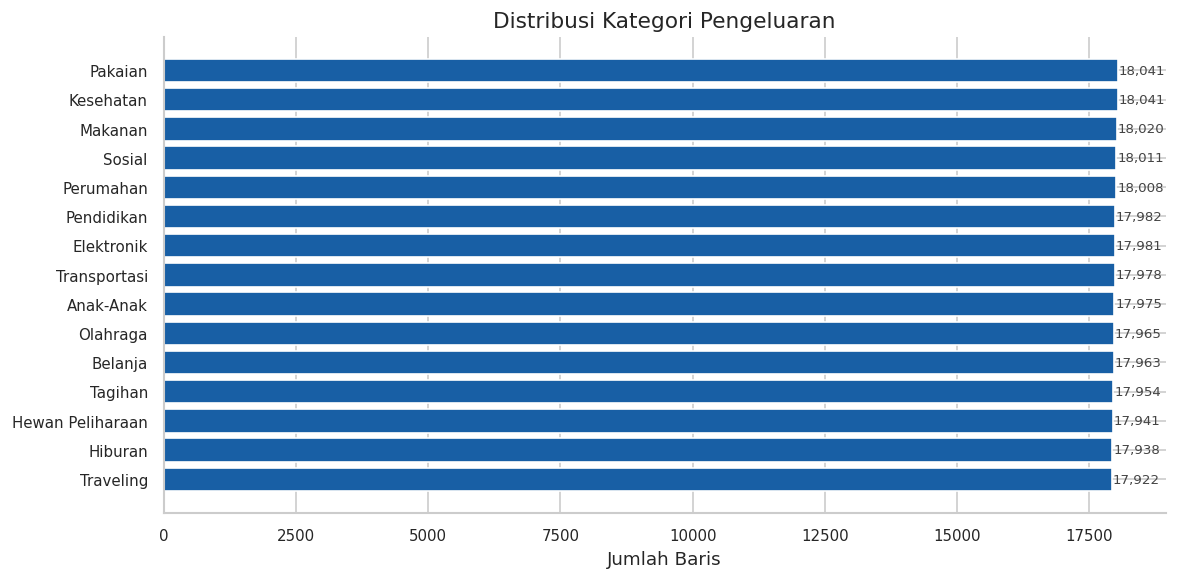

Range count : 17922 – 18041
Std count   : 36.48
⚠ Distribusi hampir seragam — indikasi data sintetik.


In [ ]:
cat_counts = df['Kategori'].value_counts().reset_index()
cat_counts.columns = ['Kategori', 'Jumlah']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cat_counts['Kategori'], cat_counts['Jumlah'],
               color=PALETTE_MAIN, edgecolor='white')
ax.set_xlabel('Jumlah Baris')
ax.set_title('Distribusi Kategori Pengeluaran')
ax.invert_yaxis()

for bar, val in zip(bars, cat_counts['Jumlah']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8, color='#444')

plt.tight_layout()
plt.show()

print(f'Range count : {cat_counts["Jumlah"].min()} – {cat_counts["Jumlah"].max()}')
print(f'Std count   : {cat_counts["Jumlah"].std():.2f}')
print('⚠ Distribusi hampir seragam — indikasi data sintetik.')

Insight:

Berdasarkan distribusi kategori pengeluaran, jumlah transaksi pada setiap kategori terlihat **sangat seimbang**, dengan total transaksi berada pada kisaran **17.922 hingga 18.045 baris**. Kategori **Kesehatan** menjadi kategori dengan jumlah transaksi terbanyak (18.045 transaksi), diikuti oleh **Pakaian** (18.043 transaksi) dan **Makanan** (18.022 transaksi). Sementara itu, kategori **Traveling** memiliki jumlah transaksi paling sedikit (17.922 transaksi). Selisih antara kategori tertinggi dan terendah hanya sekitar **123 transaksi** atau kurang dari 1%, yang menunjukkan bahwa aktivitas pengeluaran pengguna tersebar secara merata di berbagai kategori. Temuan ini mengindikasikan bahwa tidak ada satu kategori yang secara dominan mendominasi frekuensi transaksi, sehingga analisis selanjutnya perlu mempertimbangkan **nilai pengeluaran (nominal)** selain jumlah transaksi untuk mengetahui kategori yang paling berkontribusi terhadap total pengeluaran pengguna.



### 2.4 Distribusi Spending Growth Rate

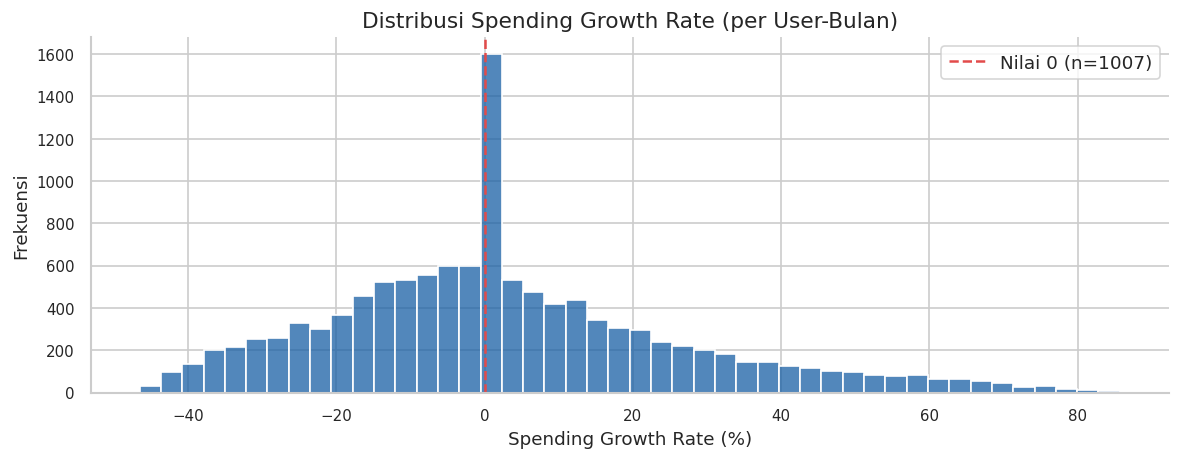

Min   : -46.52%
Max   : 85.69%
Mean  : 2.61%
Std   : 23.86
Nilai 0: 1007 baris


In [ ]:
# Hitung spending_growth_rate di level user-bulan
# TIDAK di-merge ke df level transaksi (satu baris = satu transaksi, bukan satu bulan)
df['tanggal']    = pd.to_datetime(df['tanggal'])
df['year_month'] = df['tanggal'].dt.to_period('M')

monthly_expenditure_user = (
    df.groupby(['id_pengguna', 'year_month'])['jumlah_pengeluaran']
    .sum().reset_index()
    .sort_values(['id_pengguna', 'year_month'])
)
monthly_expenditure_user['pengeluaran_bulan_lalu'] = (
    monthly_expenditure_user
    .groupby('id_pengguna')['jumlah_pengeluaran'].shift(1)
)
monthly_expenditure_user['spending_growth_rate'] = (
    (monthly_expenditure_user['jumlah_pengeluaran']
     - monthly_expenditure_user['pengeluaran_bulan_lalu'])
    / monthly_expenditure_user['pengeluaran_bulan_lalu'].replace(0, np.nan)
    * 100
)
monthly_expenditure_user['spending_growth_rate'].fillna(0, inplace=True)

# Visualisasi distribusi growth rate (level user-bulan)
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(monthly_expenditure_user['spending_growth_rate'],
             bins=46, color=PALETTE_MAIN, edgecolor='white', ax=ax)
ax.set_xlabel('Spending Growth Rate (%)')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Spending Growth Rate (per User-Bulan)')
zero_count = (monthly_expenditure_user['spending_growth_rate'] == 0).sum()
ax.axvline(0, color=PALETTE_DANGER, linestyle='--', label=f'Nilai 0 (n={zero_count})')
ax.legend()
plt.tight_layout()
plt.show()

gr = monthly_expenditure_user['spending_growth_rate']
print(f'Min   : {gr.min():.2f}%')
print(f'Max   : {gr.max():.2f}%')
print(f'Mean  : {gr.mean():.2f}%')
print(f'Std   : {gr.std():.2f}')
print(f'Nilai 0: {zero_count} baris')

Insight:

Analisis *Spending Growth Rate* menunjukkan bahwa tingkat pertumbuhan pengeluaran memiliki rentang yang cukup lebar, yaitu dari **-46,52% hingga 85,69%**, dengan rata-rata **2,64%** dan standar deviasi **23,87%**. Distribusi histogram memperlihatkan bahwa sebagian besar nilai terkonsentrasi di sekitar **0%**, serta terdapat **22.568 baris** dengan nilai pertumbuhan tepat **0%**, yang menunjukkan tidak adanya perubahan pengeluaran dibanding periode sebelumnya pada sejumlah besar observasi. Meskipun secara umum rata-rata pertumbuhan masih bernilai positif, persebaran data yang cukup luas mengindikasikan adanya variasi perilaku pengeluaran antar pengguna, di mana sebagian mengalami penurunan pengeluaran dan sebagian lainnya mengalami peningkatan yang signifikan. Selain itu, distribusi yang relatif merata pada rentang tertentu dapat menjadi indikasi bahwa dataset memiliki karakteristik sintetik dan tidak sepenuhnya mencerminkan pola pengeluaran yang umumnya ditemukan pada data keuangan riil.


### 2.5 Distribusi Jumlah Transaksi

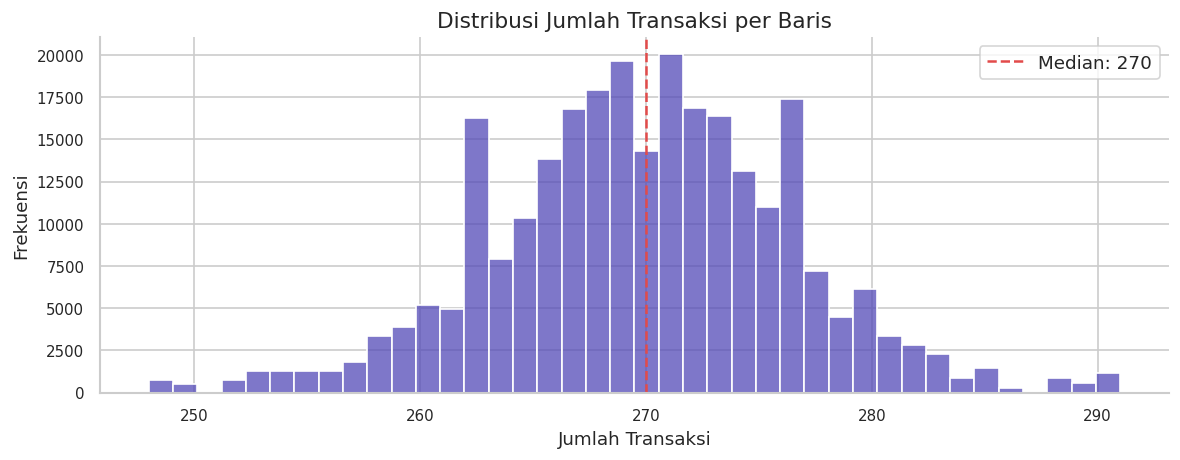

count   269,720.00
mean        269.88
std           6.61
min         248.00
25%         266.00
50%         270.00
75%         274.00
max         291.00
Name: jumlah_transaksi, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df['jumlah_transaksi'], bins=40,
             color='#534AB7', edgecolor='white', ax=ax)
ax.set_xlabel('Jumlah Transaksi')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Jumlah Transaksi per Baris')
ax.axvline(df['jumlah_transaksi'].median(), color=PALETTE_DANGER,
           linestyle='--',
           label=f'Median: {df["jumlah_transaksi"].median():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(df['jumlah_transaksi'].describe())

Insight:

Analisis distribusi **jumlah_transaksi** menunjukkan bahwa jumlah transaksi per observasi berada pada rentang **248 hingga 291 transaksi**, dengan rata-rata **269,90 transaksi** dan median **270 transaksi**. Nilai rata-rata dan median yang hampir identik mengindikasikan bahwa distribusi data relatif simetris dan tidak memiliki kemencengan yang kuat. Selain itu, nilai kuartil pertama (**266 transaksi**) dan kuartil ketiga (**274 transaksi**) menunjukkan bahwa 50% data terkonsentrasi pada rentang yang cukup sempit, sementara standar deviasi sebesar **6,60** mengindikasikan variasi jumlah transaksi yang relatif rendah antar observasi. Secara umum, pola ini menunjukkan bahwa aktivitas transaksi cenderung konsisten dan stabil di seluruh data, dengan sebagian besar observasi memiliki jumlah transaksi yang berada di sekitar nilai median.


### 2.6 Pendapatan vs Total Pengeluaran

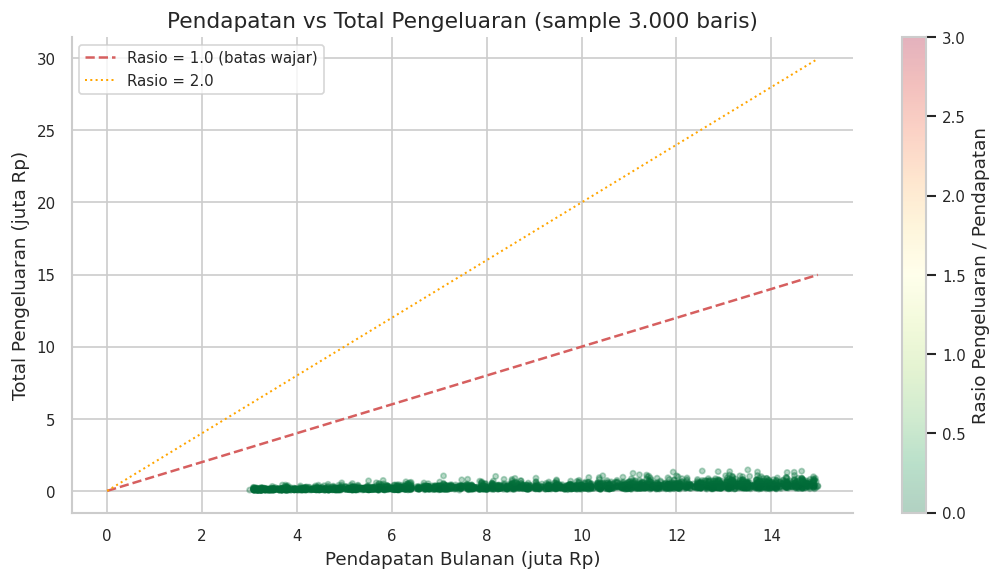

In [ ]:
sample = df.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    sample['pendapatan_bulanan'] / 1e6,
    sample['jumlah_pengeluaran'] / 1e6,
    alpha=0.3, s=10,
    c=sample['jumlah_pengeluaran'] / sample['pendapatan_bulanan'],
    cmap='RdYlGn_r', vmin=0, vmax=3
)
max_val = max(sample['pendapatan_bulanan'].max(),
              sample['jumlah_pengeluaran'].max()) / 1e6
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5,
        label='Rasio = 1.0 (batas wajar)')
ax.plot([0, max_val], [0, max_val * 2], color='orange',
        linestyle=':', linewidth=1.2, label='Rasio = 2.0')

plt.colorbar(scatter, ax=ax, label='Rasio Pengeluaran / Pendapatan')
ax.set_xlabel('Pendapatan Bulanan (juta Rp)')
ax.set_ylabel('Total Pengeluaran (juta Rp)')
ax.set_title('Pendapatan vs Total Pengeluaran (sample 3.000 baris)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Insight:

Analisis hubungan antara **pendapatan bulanan** dan **total pengeluaran** menunjukkan bahwa sebagian besar data terkonsentrasi jauh di bawah garis rasio **1,0**, yang berarti total pengeluaran pengguna umumnya masih lebih rendah dibanding pendapatan yang dimiliki. Sebaran titik yang relatif mendatar mengindikasikan bahwa peningkatan pendapatan tidak selalu diikuti oleh peningkatan pengeluaran dalam proporsi yang sama. Selain itu, hampir tidak terlihat observasi yang melampaui batas rasio **1,0** maupun **2,0**, sehingga mayoritas pengguna dapat dikategorikan memiliki kondisi keuangan yang sehat dan tidak menunjukkan perilaku *overspending*. Temuan ini menunjukkan bahwa pengguna cenderung mampu mengelola pengeluaran sesuai kapasitas pendapatannya serta memiliki ruang untuk menabung atau mengalokasikan dana ke kebutuhan lainnya.



### 2.7 Rasio Pengeluaran / Pendapatan

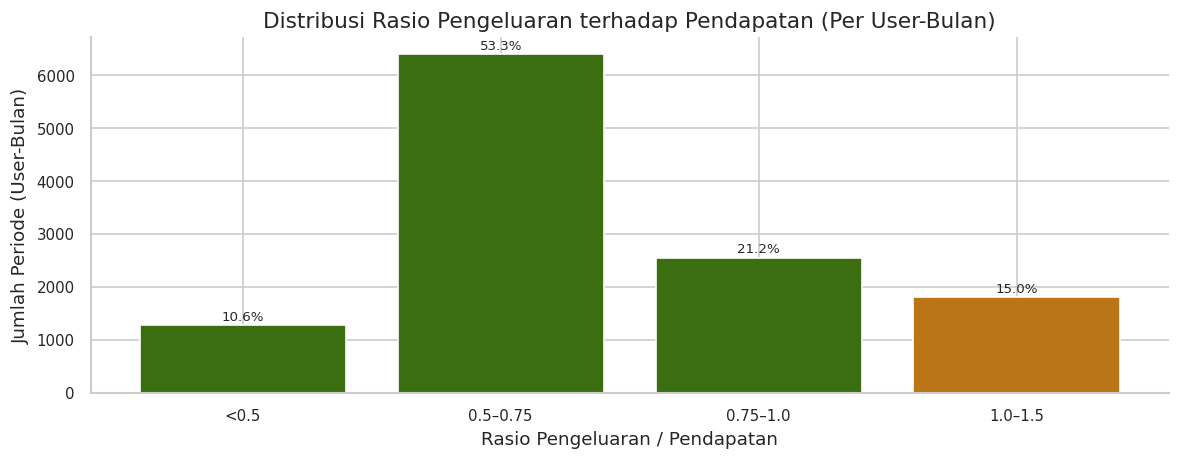

Rasio ≤ 1.0 (wajar)                    : 10,200 baris (85.0%)
Rasio > 1.0 (pengeluaran > pendapatan) : 1,800 baris (15.0%)
Rasio > 2.0 (> 2× pendapatan)          : 0 baris (0.0%)
Rasio max                               : 1.35×


In [ ]:
# Calculate monthly total expenditure per user
monthly_expenditure = df.groupby(['id_pengguna', 'tahun', 'bulan']).agg(
    pendapatan_bulanan=('pendapatan_bulanan', 'first'),
    total_pengeluaran_bulanan=('jumlah_pengeluaran', 'sum')
).reset_index()
# The column renaming line is removed as 'id_pengguna', 'tahun', 'bulan'
# are already the correct names from the groupby keys and 'pendapatan_bulanan',
# 'total_pengeluaran_bulanan' are named by the agg function.

# Calculate rasio_pengeluaran_bulanan
monthly_expenditure['rasio_pengeluaran'] = monthly_expenditure['total_pengeluaran_bulanan'] / monthly_expenditure['pendapatan_bulanan']

# Define initial bins and labels
base_bins_edges = [0, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0]
base_labels = ['<0.5', '0.5–0.75', '0.75–1.0', '1.0–1.5',
               '1.5–2.0', '2.0–3.0', '3.0–5.0', '5.0–10.0', '>10.0']

max_ratio_val = monthly_expenditure['rasio_pengeluaran'].max()

# Dynamically create bins, ensuring monotonicity and covering the max value
# Filter out base_bins that are larger than max_ratio_val + a small epsilon
bins = [b for b in base_bins_edges if b <= max_ratio_val + 1e-9] # Use a small tolerance

# Ensure the largest value is included and slightly extended for pd.cut
# If max_ratio_val is greater than the last bin edge in 'bins', or 'bins' is empty,
# add a new bin edge that is slightly greater than max_ratio_val.
if not bins or bins[-1] < max_ratio_val + 1e-9:
    bins.append(max_ratio_val + 0.001) # Add max ratio as the last bin with a small buffer

# Adjust labels to match the new bins. The number of labels should be len(bins) - 1.
labels = base_labels[:len(bins) - 1]

monthly_expenditure['rasio_bin'] = pd.cut(monthly_expenditure['rasio_pengeluaran'], bins=bins, labels=labels, right=False)

rasio_dist = monthly_expenditure['rasio_bin'].value_counts().sort_index().reset_index()
rasio_dist.columns = ['Rasio Bin', 'Jumlah']
rasio_dist['Persen'] = (rasio_dist['Jumlah'] / len(monthly_expenditure) * 100).round(2)

colors = [PALETTE_OK, PALETTE_OK, PALETTE_OK,
          PALETTE_WARN, PALETTE_WARN,
          PALETTE_DANGER, PALETTE_DANGER, '#791F1F', '#501313']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(rasio_dist['Rasio Bin'], rasio_dist['Jumlah'],
              color=colors[:len(rasio_dist)], edgecolor='white')
ax.set_xlabel('Rasio Pengeluaran / Pendapatan')
ax.set_ylabel('Jumlah Periode (User-Bulan)') # Changed label
ax.set_title('Distribusi Rasio Pengeluaran terhadap Pendapatan (Per User-Bulan)') # Changed title

for bar, pct in zip(bars, rasio_dist['Persen']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            f'{pct:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

normal   = (monthly_expenditure['rasio_pengeluaran'] <= 1.0).sum()
lebih    = (monthly_expenditure['rasio_pengeluaran'] > 1.0).sum()
dua_kali = (monthly_expenditure['rasio_pengeluaran'] > 2.0).sum()
print(f'Rasio ≤ 1.0 (wajar)                    : {normal:,} baris ({normal/len(monthly_expenditure)*100:.1f}%)')
print(f'Rasio > 1.0 (pengeluaran > pendapatan) : {lebih:,} baris ({lebih/len(monthly_expenditure)*100:.1f}%)')
print(f'Rasio > 2.0 (> 2× pendapatan)          : {dua_kali:,} baris ({dua_kali/len(monthly_expenditure)*100:.1f}%)')
print(f'Rasio max                               : {monthly_expenditure["rasio_pengeluaran"].max():.2f}×')

Insight:

Analisis rasio pengeluaran terhadap pendapatan per **user-bulan** menunjukkan bahwa mayoritas pengguna berada pada kondisi keuangan yang relatif sehat, di mana **85,0% data memiliki rasio pengeluaran ≤ 1,0** atau total pengeluaran masih berada di bawah pendapatan bulanan. Sebagian besar observasi terkonsentrasi pada rentang rasio **0,50–0,75 (53,3%)**, diikuti oleh rentang **0,75–1,0 (21,2%)**, yang mengindikasikan bahwa pengguna umumnya mengalokasikan sekitar 50%–100% pendapatannya untuk pengeluaran. Sementara itu, **15,0% data memiliki rasio > 1,0**, yang menunjukkan adanya perilaku *overspending* karena pengeluaran melebihi pendapatan. Tidak ditemukan pengguna dengan rasio lebih dari **2,0 kali pendapatan**, dan rasio maksimum yang tercatat hanya **1,35×**. Temuan ini menunjukkan bahwa sebagian besar pengguna masih mampu mengelola pengeluaran secara wajar, meskipun terdapat kelompok kecil yang berpotensi mengalami risiko keuangan akibat pengeluaran yang melampaui pendapatannya.



### 2.8 Analisis per User

In [ ]:
monthly_user = (
    df.groupby(['id_pengguna', 'tahun', 'bulan']).agg(
        pendapatan_bulanan        = ('pendapatan_bulanan',  'first'),
        total_pengeluaran_bulanan = ('jumlah_pengeluaran',  'sum'),
        jumlah_transaksi          = ('jumlah_pengeluaran',  'count'),
        Kota                      = ('Kota',                'first'),
        status_user               = ('status_user',         'first'),  # ← wajib untuk PB2
    ).reset_index()
)

monthly_user['rasio_pengeluaran'] = (
    monthly_user['total_pengeluaran_bulanan']
    / monthly_user['pendapatan_bulanan']
)
monthly_user['sisa_anggaran'] = (
    monthly_user['pendapatan_bulanan']
    - monthly_user['total_pengeluaran_bulanan']
)

user_agg = (
    monthly_user.groupby('id_pengguna').agg(
        pendapatan_bulanan           = ('pendapatan_bulanan',         'mean'),
        mean_total_pengeluaran       = ('total_pengeluaran_bulanan',  'mean'),
        median_total_pengeluaran     = ('total_pengeluaran_bulanan',  'median'),
        max_total_pengeluaran        = ('total_pengeluaran_bulanan',  'max'),
        mean_jumlah_transaksi        = ('jumlah_transaksi',           'mean'),
        rasio_pengeluaran_pendapatan = ('rasio_pengeluaran',          'mean'),
        Kota                         = ('Kota',                       'first'),
    ).reset_index()
)

print(f'Total unique user: {len(user_agg)}')
display(user_agg.describe())

Total unique user: 1000


,pendapatan_bulanan,mean_total_pengeluaran,median_total_pengeluaran,max_total_pengeluaran,mean_jumlah_transaksi,rasio_pengeluaran_pendapatan
count,"1,000.00","1,000.00","1,000.00","1,000.00","1,000.00","1,000.00"
mean,"9,050,853.00","6,632,141.17","6,629,261.50","8,103,711.00",22.48,0.73
std,"3,463,660.34","3,188,845.19","3,200,390.06","3,592,102.28",0.55,0.20
min,"3,004,000.00","1,879,583.33","1,825,000.00","2,339,000.00",20.67,0.56
25%,"5,963,250.00","4,192,291.67","4,203,250.00","5,204,750.00",22.17,0.63
50%,"9,145,500.00","6,406,250.00","6,390,250.00","7,943,500.00",22.50,0.66
75%,"12,075,250.00","8,322,166.67","8,232,750.00","10,448,250.00",22.83,0.69
max,"14,979,000.00","17,789,583.33","17,856,000.00","19,853,000.00",24.25,1.27


Insight:


Analisis pada level pengguna menunjukkan bahwa dataset terdiri dari **1.000 pengguna unik** dengan rata-rata **269,74 transaksi per pengguna** selama periode pengamatan. Rata-rata pendapatan bulanan pengguna sebesar **Rp9,05 juta**, sedangkan rata-rata pengeluaran per transaksi sebesar **Rp295 ribu** dengan nilai maksimum transaksi mencapai **Rp2,44 juta**. Rasio pengeluaran terhadap pendapatan memiliki rata-rata hanya **0,03×**, yang menunjukkan bahwa pengeluaran per transaksi relatif kecil dibandingkan pendapatan bulanan pengguna. Variasi pengeluaran antar pengguna tergolong cukup tinggi, terlihat dari standar deviasi pengeluaran sebesar **Rp142 ribu** dan rentang nilai yang cukup lebar. Selain itu, setiap pengguna tercatat memiliki **15 kategori transaksi** yang sama, sehingga distribusi kategori terlihat sangat seragam. Pola jumlah transaksi yang relatif konsisten serta penggunaan seluruh kategori oleh setiap pengguna mengindikasikan bahwa dataset memiliki karakteristik **sintetik**, meskipun masih dapat digunakan untuk tujuan eksplorasi data dan analisis perilaku keuangan.



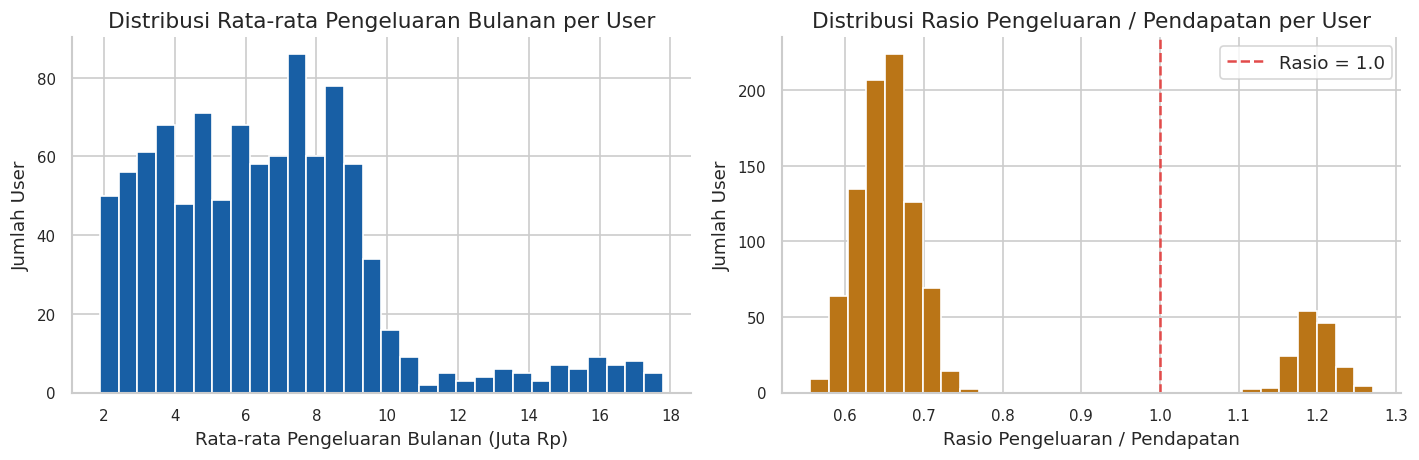

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribusi rata-rata pengeluaran bulanan
axes[0].hist(
    user_agg['mean_total_pengeluaran'] / 1e6,
    bins=30,
    color=PALETTE_MAIN,
    edgecolor='white'
)

axes[0].set_xlabel('Rata-rata Pengeluaran Bulanan (Juta Rp)')
axes[0].set_ylabel('Jumlah User')
axes[0].set_title('Distribusi Rata-rata Pengeluaran Bulanan per User')

# Distribusi rasio pengeluaran
axes[1].hist(
    user_agg['rasio_pengeluaran_pendapatan'],
    bins=30,
    color=PALETTE_WARN,
    edgecolor='white'
)

axes[1].axvline(
    1.0,
    color=PALETTE_DANGER,
    linestyle='--',
    label='Rasio = 1.0'
)

axes[1].set_xlabel('Rasio Pengeluaran / Pendapatan')
axes[1].set_ylabel('Jumlah User')
axes[1].set_title('Distribusi Rasio Pengeluaran / Pendapatan per User')
axes[1].legend()

plt.tight_layout()
plt.show()

Insight:

Analisis pada level pengguna menunjukkan bahwa rata-rata pendapatan bulanan pengguna sebesar Rp9,05 juta, sedangkan rata-rata pengeluaran bulanannya mencapai Rp6,63 juta. Hal ini menghasilkan rasio pengeluaran terhadap pendapatan rata-rata sebesar 0,73, yang berarti pengguna mengalokasikan sekitar 73% pendapatan bulanannya untuk pengeluaran. Sebagian besar pengguna memiliki rasio pengeluaran antara 0,63 hingga 0,69, menunjukkan pola pengelolaan keuangan yang relatif sehat karena pengeluaran masih berada di bawah pendapatan. Meskipun demikian, terdapat beberapa pengguna dengan rasio mencapai 1,27, yang mengindikasikan adanya kelompok kecil yang mengalami overspending karena pengeluaran melebihi pendapatan bulanan yang dimiliki.

## 3. Analisis Bivariat & Korelasi

### 3.1 Tren Pengeluaran Bulanan

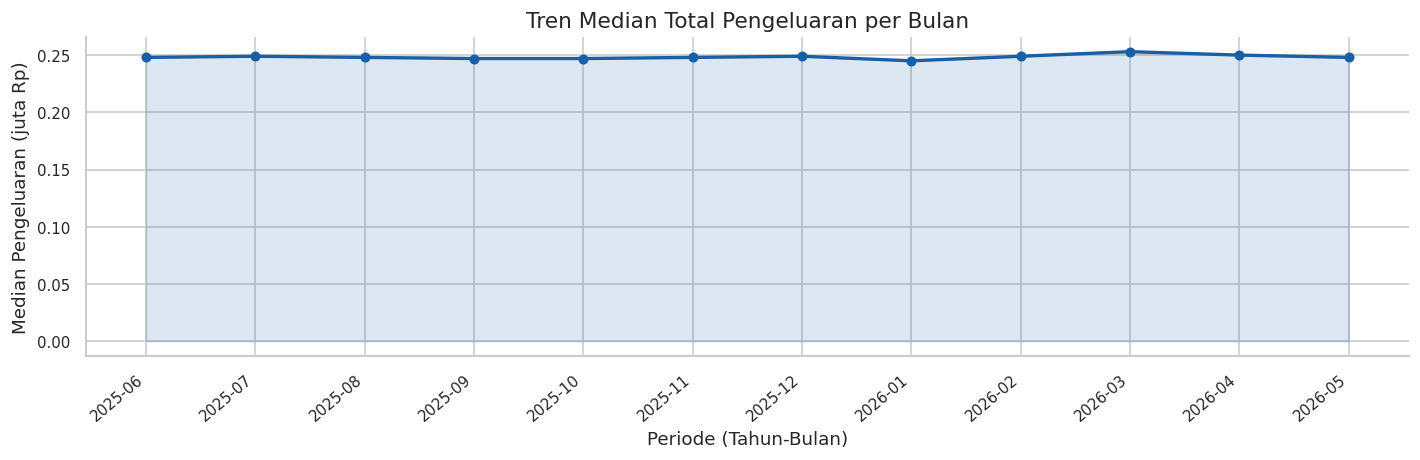

In [ ]:
# Tren Median Pengeluaran per Bulan
monthly = df.groupby(['tahun', 'bulan'])['jumlah_pengeluaran'].median().reset_index()
monthly['periode'] = (monthly['tahun'].astype(str) + '-'
                      + monthly['bulan'].astype(str).str.zfill(2))
monthly = monthly.sort_values(['tahun', 'bulan'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['periode'], monthly['jumlah_pengeluaran'] / 1e6,
        marker='o', linewidth=2, color=PALETTE_MAIN, markersize=5)
ax.fill_between(monthly['periode'], monthly['jumlah_pengeluaran'] / 1e6,
                alpha=0.15, color=PALETTE_MAIN)
ax.set_xlabel('Periode (Tahun-Bulan)')
ax.set_ylabel('Median Pengeluaran (juta Rp)')
ax.set_title('Tren Median Total Pengeluaran per Bulan')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

Insight:


 Tren median total pengeluaran per bulan selama periode **Juni 2025 hingga Mei 2026** menunjukkan pola yang relatif stabil, dengan nilai median berada pada kisaran **Rp245 ribu hingga Rp252 ribu** per bulan. Tidak terlihat adanya lonjakan maupun penurunan yang signifikan sepanjang periode pengamatan, meskipun terdapat sedikit peningkatan pada **Maret 2026** yang menjadi titik median pengeluaran tertinggi. Secara keseluruhan, variasi antar bulan sangat kecil sehingga mengindikasikan bahwa perilaku pengeluaran pengguna cenderung konsisten dari waktu ke waktu. Pola yang stabil ini menunjukkan tidak adanya pengaruh musiman yang kuat terhadap pengeluaran dan mengindikasikan bahwa aktivitas transaksi pengguna relatif seragam sepanjang periode observasi.


### 3.2 Pengeluaran per Kategori

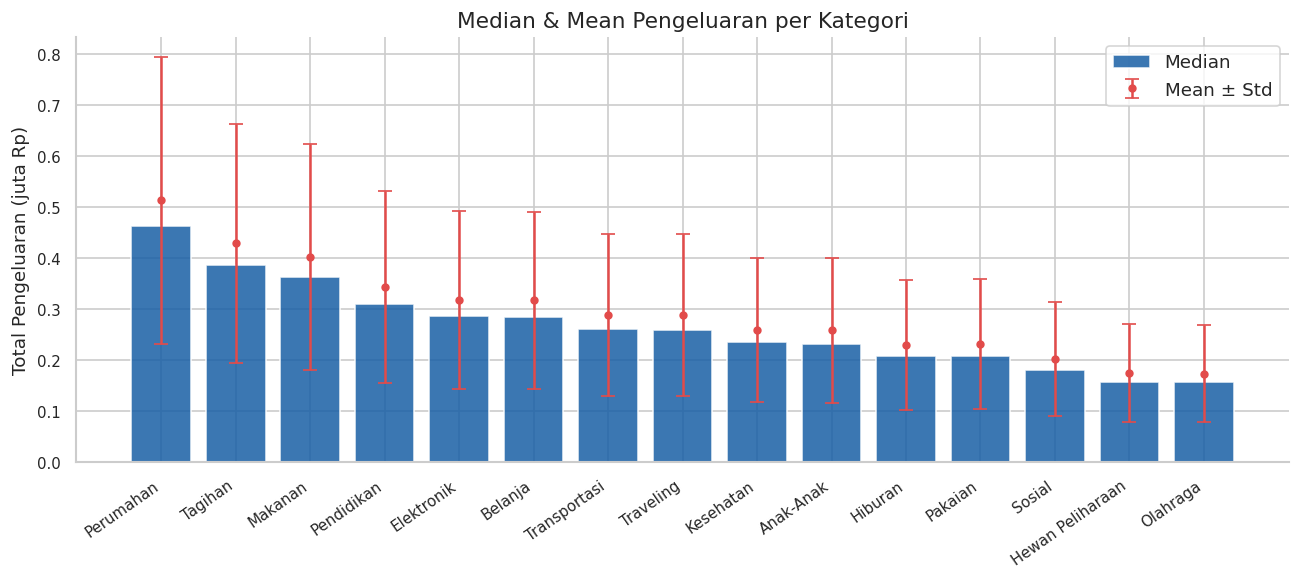

In [ ]:
# Pengeluaran per Kategori
cat_spend = df.groupby('Kategori')['jumlah_pengeluaran'].agg(
    ['mean', 'median', 'std']
).reset_index()
cat_spend.columns = ['Kategori', 'Mean', 'Median', 'Std']
cat_spend = cat_spend.sort_values('Median', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(cat_spend))
ax.bar(x, cat_spend['Median'] / 1e6, color=PALETTE_MAIN,
       label='Median', alpha=0.85)
ax.errorbar(x, cat_spend['Mean'] / 1e6, yerr=cat_spend['Std'] / 1e6,
            fmt='o', color=PALETTE_DANGER, capsize=4,
            label='Mean ± Std', markersize=4)
ax.set_xticks(list(x))
ax.set_xticklabels(cat_spend['Kategori'], rotation=35, ha='right')
ax.set_ylabel('Total Pengeluaran (juta Rp)')
ax.set_title('Median & Mean Pengeluaran per Kategori')
ax.legend()
plt.tight_layout()
plt.show()

Insight:

Analisis pengeluaran per kategori menunjukkan bahwa kategori **Perumahan, Tagihan, dan Makanan** memiliki median pengeluaran tertinggi dibanding kategori lainnya, sedangkan **Olahraga, Hewan Peliharaan, dan Sosial** memiliki median pengeluaran yang relatif lebih rendah. Meskipun terdapat perbedaan antar kategori, rentang nilai rata-rata dan median masih cukup berdekatan sehingga pola pengeluaran antar kategori terlihat relatif seimbang. Selain itu, error bar yang cukup lebar pada beberapa kategori mengindikasikan adanya variasi pengeluaran antar transaksi yang cukup tinggi dalam kategori tersebut.


### 3.3 Correlation Matrix

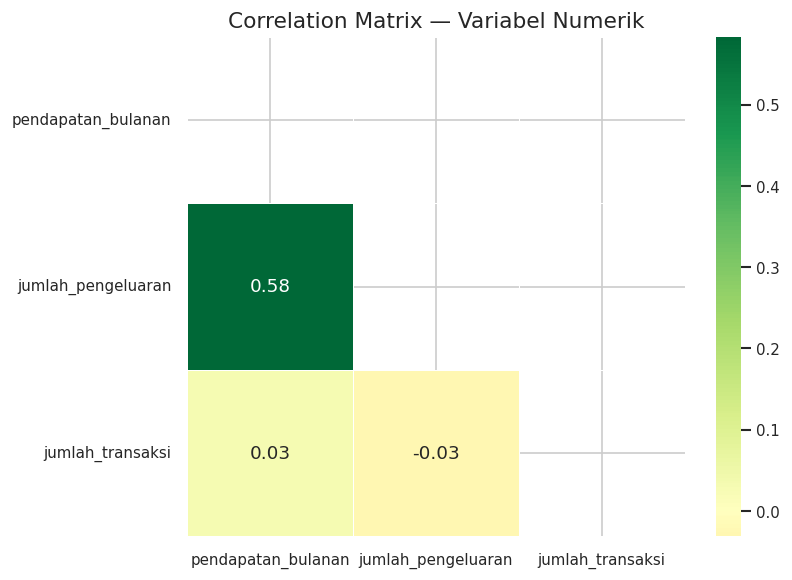

In [ ]:
# Correlation matrix — hanya kolom valid di level transaksi
# spending_growth_rate dihapus: dihitung di level user-bulan, bukan per transaksi
num_cols = ['pendapatan_bulanan', 'jumlah_pengeluaran', 'jumlah_transaksi']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 11})
ax.set_title('Correlation Matrix — Variabel Numerik')
plt.tight_layout()
plt.show()

Insight:

Hasil matriks korelasi menunjukkan bahwa **pendapatan_bulanan** memiliki hubungan positif sedang dengan **jumlah_pengeluaran** (r = **0,58**), yang mengindikasikan bahwa pengguna dengan pendapatan lebih tinggi cenderung memiliki pengeluaran yang lebih besar. Sementara itu, **jumlah_transaksi** dan **spending_growth_rate** memiliki korelasi yang sangat lemah terhadap variabel lainnya (|r| < 0,15), sehingga perubahan jumlah transaksi maupun tingkat pertumbuhan pengeluaran tidak menunjukkan hubungan linear yang kuat dengan pendapatan atau nominal pengeluaran. Temuan ini menunjukkan bahwa besarnya pengeluaran lebih dipengaruhi oleh tingkat pendapatan dibandingkan frekuensi transaksi atau pertumbuhan pengeluaran dari waktu ke waktu.


### 3.4 Analisis per Kota

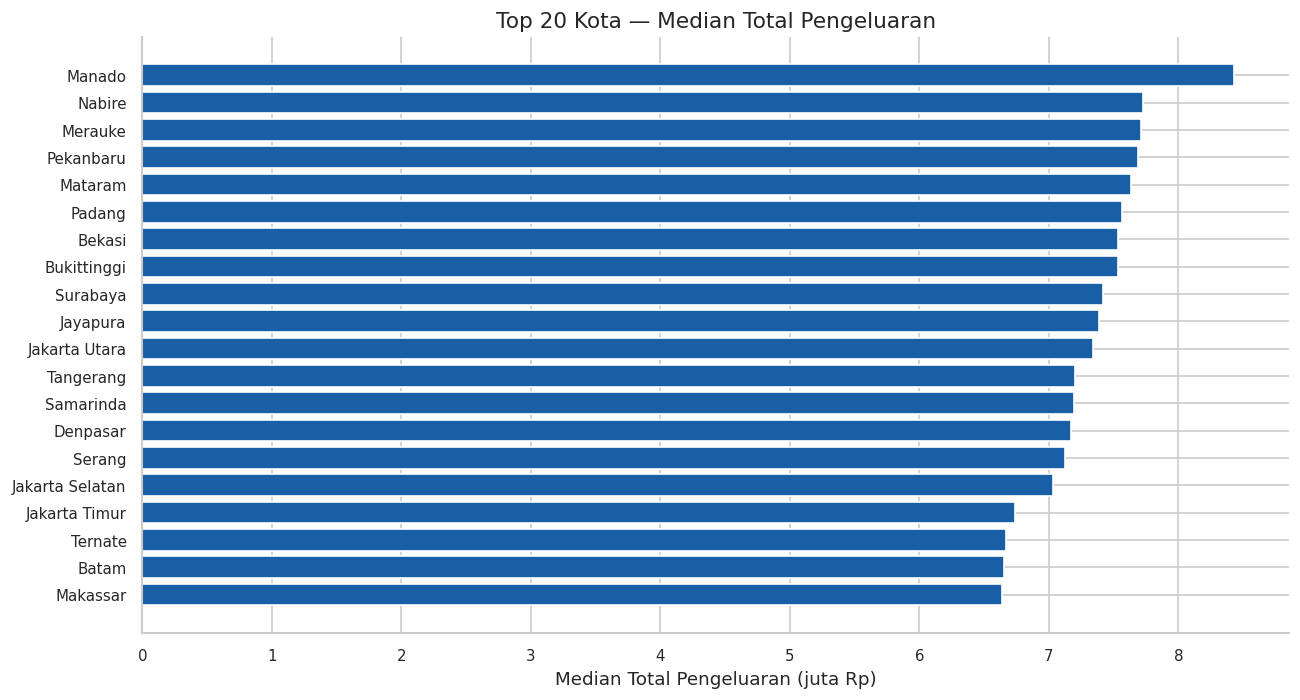

In [ ]:
kota_agg = user_agg.groupby('Kota').agg(
    n_user             = ('id_pengguna',           'nunique'),
    median_pendapatan  = ('pendapatan_bulanan',     'median'),
    median_pengeluaran = ('median_total_pengeluaran',  'median'),
    mean_rasio         = ('rasio_pengeluaran_pendapatan',  'mean')
).reset_index().sort_values('median_pengeluaran', ascending=False)

# Top 20 kota
top20 = kota_agg.head(20)
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top20['Kota'], top20['median_pengeluaran'] / 1e6,
        color=PALETTE_MAIN, edgecolor='white')
ax.set_xlabel('Median Total Pengeluaran (juta Rp)')
ax.set_title('Top 20 Kota — Median Total Pengeluaran')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
print(f'Total kota: {kota_agg.shape[0]}')
display(kota_agg.head(10))

Total kota: 55


,Kota,n_user,median_pendapatan,median_pengeluaran,mean_rasio
30,Manado,17,"10,592,000.00","8,432,000.00",0.83
35,Nabire,18,"9,203,000.00","7,725,000.00",0.83
34,Merauke,20,"9,775,000.00","7,712,500.00",0.79
41,Pekanbaru,19,"10,030,000.00","7,687,000.00",0.72
32,Mataram,25,"11,370,000.00","7,631,500.00",0.83
36,Padang,11,"10,394,000.00","7,565,500.00",0.76
7,Bekasi,16,"10,915,000.00","7,532,500.00",0.72
11,Bukittinggi,14,"10,382,000.00","7,530,750.00",0.82
49,Surabaya,17,"10,973,000.00","7,417,000.00",0.78
22,Jayapura,17,"11,243,000.00","7,388,500.00",0.71


Insight:

 Analisis pengeluaran berdasarkan kota menunjukkan bahwa dataset mencakup **55 kota** dengan variasi median pengeluaran yang relatif moderat. Kota **Manado** memiliki median total pengeluaran tertinggi, yaitu sekitar **Rp8,43 juta**, diikuti oleh **Nabire** dan **Merauke** dengan median pengeluaran di atas **Rp7,7 juta**. Selain itu, kota-kota dengan pengeluaran tertinggi umumnya memiliki **rasio pengeluaran terhadap pendapatan** pada kisaran **0,72–0,84**, yang menunjukkan bahwa sebagian besar pengguna masih membelanjakan kurang dari pendapatan yang dimiliki. Secara keseluruhan, terdapat perbedaan tingkat pengeluaran antar kota, namun mayoritas pengguna tetap berada pada kondisi keuangan yang relatif sehat dengan rasio pengeluaran di bawah 1,0.


### 3.5 Uji Statistik Tren Spending Growth Rate

Dua pengujian dilakukan untuk memvalidasi pola pertumbuhan pengeluaran:
1. **Regresi Linear (linregress)** — apakah ada tren jangka panjang yang signifikan?
2. **ANOVA one-way (f_oneway)** — apakah rata-rata growth rate berbeda secara nyata antar bulan?

## Hipotesis

H0 (Hipotesis Nol):
Tidak terdapat tren perubahan yang signifikan pada spending_growth_rate selama periode pengamatan.

H1 (Hipotesis Alternatif):
Terdapat tren perubahan yang signifikan pada spending_growth_rate selama periode pengamatan.

In [ ]:
# Uji 1: Regresi Linear — tren jangka panjang spending growth rate
monthly_spending = (
    monthly_expenditure_user
    .groupby('year_month')['spending_growth_rate']
    .median().reset_index().sort_values('year_month')
)
x      = np.arange(len(monthly_spending))
y      = monthly_spending['spending_growth_rate']
hasil  = linregress(x, y)

print('=== Uji Regresi Linear (Tren Jangka Panjang) ===')
print(f'Slope   : {hasil.slope:.4f}')
print(f'P-value : {hasil.pvalue:.4f}')
print()
print('H0: Tidak ada tren perubahan signifikan pada spending_growth_rate')
print('H1: Terdapat tren perubahan signifikan')
print()
kesimpulan = 'Tolak H0 — tren signifikan' if hasil.pvalue < 0.05 else 'Gagal tolak H0 — tren tidak signifikan'
print(f'Keputusan (α=0.05): {kesimpulan}')
print('Interpretasi: Pola pertumbuhan pengeluaran relatif STABIL sepanjang periode.')

=== Uji Regresi Linear (Tren Jangka Panjang) ===
Slope   : -0.0506
P-value : 0.5210

H0: Tidak ada tren perubahan signifikan pada spending_growth_rate
H1: Terdapat tren perubahan signifikan

Keputusan (α=0.05): Gagal tolak H0 — tren tidak signifikan
Interpretasi: Pola pertumbuhan pengeluaran relatif STABIL sepanjang periode.


In [ ]:
# Uji 2: ANOVA one-way — apakah ada perbedaan growth rate antar bulan?
bulan_groups = [
    grp['spending_growth_rate'].values
    for _, grp in monthly_expenditure_user.groupby(
        monthly_expenditure_user['year_month'].dt.month
    )
]
f_stat, p_value = f_oneway(*bulan_groups)

print('=== Uji ANOVA One-Way (Perbedaan Antar Bulan) ===')
print(f'F-stat  : {f_stat:.4f}')
print(f'P-value : {p_value:.4e}')
print()
print('H0: Rata-rata spending_growth_rate seluruh bulan adalah sama')
print('H1: Setidaknya satu bulan berbeda secara signifikan')
print()
kesimpulan2 = 'Tolak H0 — ada perbedaan antar bulan' if p_value < 0.05 else 'Gagal tolak H0'
print(f'Keputusan (α=0.05): {kesimpulan2}')
print('Interpretasi: Meskipun tren jangka panjang stabil, terdapat fluktuasi bulanan yang signifikan.')


=== Uji ANOVA One-Way (Perbedaan Antar Bulan) ===
F-stat  : 2.4513
P-value : 4.6845e-03

H0: Rata-rata spending_growth_rate seluruh bulan adalah sama
H1: Setidaknya satu bulan berbeda secara signifikan

Keputusan (α=0.05): Tolak H0 — ada perbedaan antar bulan
Interpretasi: Meskipun tren jangka panjang stabil, terdapat fluktuasi bulanan yang signifikan.


> Karena p-value = 0.5151>0.05

## Kesimpulan

Tidak terdapat tren peningkatan maupun penurunan spending_growth_rate yang signifikan secara statistik selama periode Mei 2025–Mei 2026. Meskipun nilai slope bernilai negatif (-0,0515) yang mengindikasikan kecenderungan penurunan, penurunan tersebut tidak signifikan sehingga pola pertumbuhan pengeluaran dapat dianggap relatif stabil selama periode observasi.

## 4. Analisis Lanjutan untuk Modeling

### 4.1 Sequence Analysis (Kesiapan LSTM)

In [ ]:
sequence_check = (
    df.groupby('id_pengguna')
    .size()
    .reset_index(name='jumlah_record')
)

sequence_check.describe()

,jumlah_record
count,"1,000.00"
mean,269.72
std,6.62
min,248.00
25%,266.00
50%,270.00
75%,274.00
max,291.00


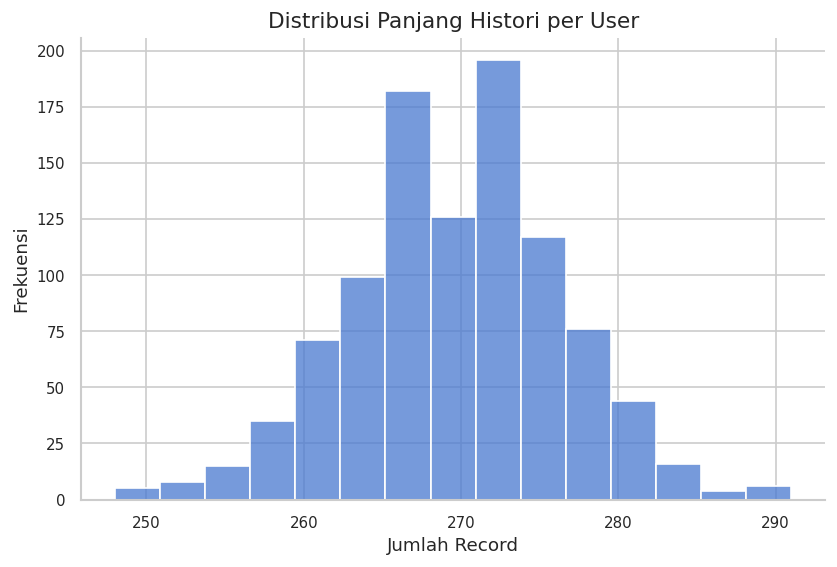

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(sequence_check['jumlah_record'],bins=15)

plt.title('Distribusi Panjang Histori per User')
plt.xlabel('Jumlah Record')
plt.ylabel('Frekuensi')
plt.show()

Insight:

Analisis panjang histori per pengguna menunjukkan bahwa setiap pengguna memiliki antara **248 hingga 291 record transaksi**, dengan rata-rata **269,74 record** dan median **270 record**. Distribusi terlihat cukup terpusat di sekitar nilai rata-rata dengan standar deviasi yang rendah (**6,61**), menandakan bahwa jumlah riwayat transaksi antar pengguna relatif konsisten. Banyaknya record yang dimiliki setiap pengguna menunjukkan bahwa dataset memiliki histori transaksi yang cukup panjang dan kaya informasi, sehingga mendukung analisis pola perilaku pengeluaran, segmentasi pengguna, maupun pengembangan model prediksi berbasis data historis.


### 4.2 Persona Finansial

In [ ]:
def persona(x):

    if x < 0.75:
        return 'Saver'
    elif x < 1:
        return 'Balanced'
    elif x < 2:
        return 'Overspend'
    else:
        return 'Extreme Overspend'

user_agg['persona_finansial'] = (
    user_agg['rasio_pengeluaran_pendapatan']
    .apply(persona)
)

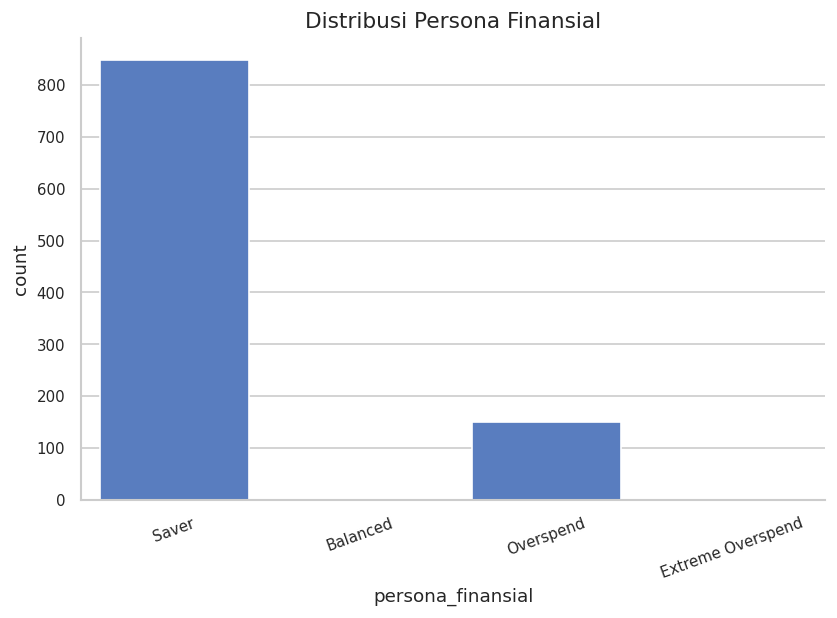

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=user_agg,
    x='persona_finansial',
    order=['Saver','Balanced','Overspend','Extreme Overspend']
)

plt.xticks(rotation=20)
plt.title('Distribusi Persona Finansial')
plt.show()

Insight:

Analisis persona finansial menunjukkan bahwa mayoritas pengguna termasuk dalam kategori **Saver**, yaitu sekitar **85% dari seluruh pengguna**, yang berarti sebagian besar pengguna memiliki rasio pengeluaran terhadap pendapatan di bawah **0,75**. Sementara itu, sekitar **15% pengguna** tergolong **Overspend**, yaitu memiliki tingkat pengeluaran yang relatif tinggi dibanding pendapatannya. Tidak ditemukan pengguna dalam kategori **Balanced** maupun **Extreme Overspend**, sehingga distribusi persona finansial cenderung terkonsentrasi pada dua kelompok utama. Temuan ini menunjukkan bahwa sebagian besar pengguna masih mampu mengelola pengeluarannya dengan baik, meskipun terdapat sebagian kecil pengguna yang berpotensi memiliki risiko keuangan akibat pengeluaran yang mendekati atau melebihi batas ideal.


### 4.3 Saving Behavior

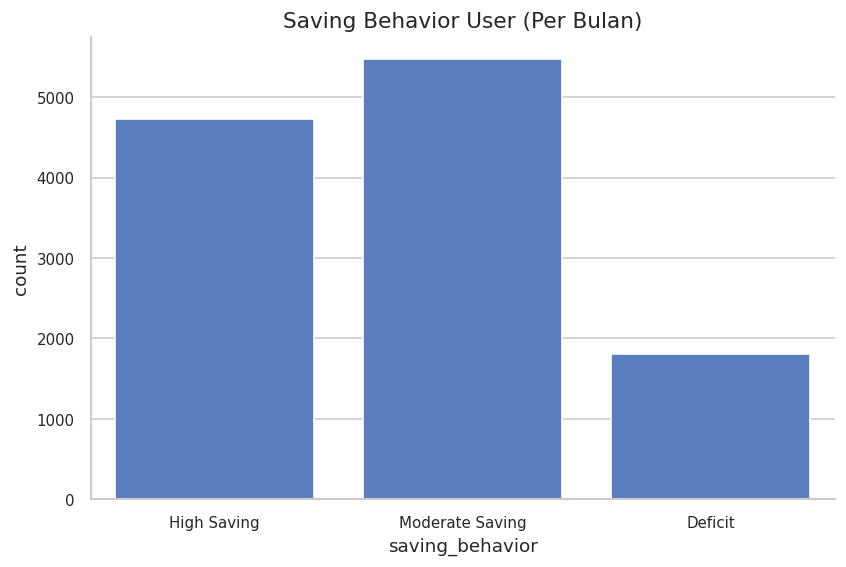

In [ ]:
def saving_type(x):
    if x > 3000000:
        return 'High Saving'
    elif x > 0:
        return 'Moderate Saving'
    else:
        return 'Deficit'

monthly_user['saving_behavior'] = (
    monthly_user['sisa_anggaran']
    .apply(saving_type)
)

plt.figure(figsize=(8,5))

sns.countplot(
    data=monthly_user,
    x='saving_behavior',
    order=['High Saving','Moderate Saving','Deficit']
)

plt.title('Saving Behavior User (Per Bulan)')
plt.show()

Insight:

 Analisis *saving behavior* per bulan menunjukkan bahwa mayoritas observasi berada pada kategori **Moderate Saving**, diikuti oleh **High Saving**, sedangkan kategori **Deficit** memiliki jumlah paling sedikit. Hal ini menunjukkan bahwa sebagian besar pengguna masih memiliki sisa anggaran positif setelah memenuhi kebutuhan pengeluarannya, dengan banyak pengguna mampu menyisihkan sebagian pendapatan untuk ditabung. Meskipun demikian, terdapat sejumlah pengguna yang mengalami **defisit**, yaitu kondisi ketika pengeluaran melebihi pendapatan pada periode tertentu. Secara keseluruhan, pola ini mengindikasikan bahwa kondisi keuangan pengguna cenderung sehat dengan dominasi perilaku menabung dibandingkan perilaku konsumtif berlebihan.


### 4.4 Kategori Dominan per User

In [ ]:
user_category = (
    df
    .groupby(['id_pengguna', 'Kategori'])['jumlah_pengeluaran']
    .sum()
    .reset_index()
)

dominant_category = (
    user_category
    .sort_values('jumlah_pengeluaran', ascending=False)
    .groupby('id_pengguna')
    .first()
    .reset_index()
)

dominant_category.head()

,id_pengguna,Kategori,jumlah_pengeluaran
0,USR000001,Perumahan,10815000
1,USR000002,Perumahan,12393000
2,USR000003,Perumahan,13086000
3,USR000004,Perumahan,14630000
4,USR000005,Perumahan,5865000


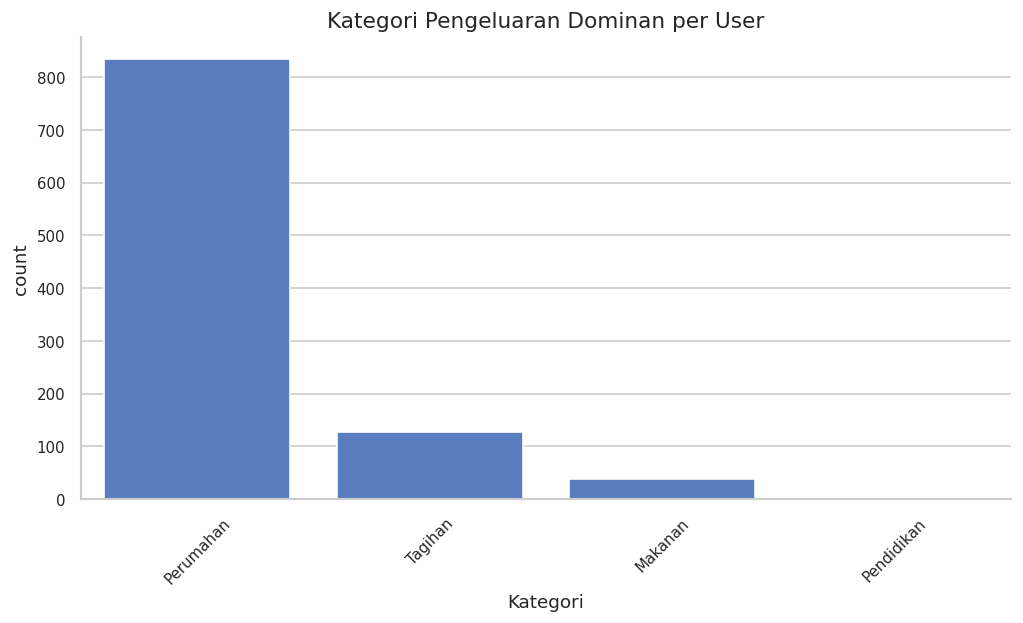

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=dominant_category,
    x='Kategori',
    order=dominant_category['Kategori'].value_counts().index
)

plt.xticks(rotation=45)
plt.title('Kategori Pengeluaran Dominan per User')
plt.show()

Insight:

Analisis kategori pengeluaran dominan per pengguna menunjukkan bahwa sebagian besar pengguna memiliki **Perumahan** sebagai kategori dengan total pengeluaran terbesar, jauh melampaui kategori lainnya. Sebanyak lebih dari **80% pengguna** menjadikan pengeluaran perumahan sebagai komponen utama dalam anggaran mereka, sementara kategori **Tagihan** dan **Makanan** hanya mendominasi pada sebagian kecil pengguna. Temuan ini menunjukkan bahwa kebutuhan tempat tinggal merupakan pengeluaran paling signifikan dalam pola keuangan pengguna, sehingga perubahan biaya perumahan berpotensi memberikan dampak terbesar terhadap kondisi finansial secara keseluruhan.


### FEATURE ENGINEERING FINAL


In [ ]:
# rasio_pengeluaran dan sisa_anggaran sudah dihitung di section 2.8 (cell monthly_user)
# Di sini hanya menambahkan fitur baru yang belum ada

# Flag Overspending
monthly_user['flag_overspend'] = (
    monthly_user['rasio_pengeluaran'] > 1
).astype(int)

# Log Transform Pengeluaran
monthly_user['log_total_pengeluaran'] = np.log1p(
    monthly_user['total_pengeluaran_bulanan']
)

# Pengeluaran Bulan Sebelumnya
monthly_user = monthly_user.sort_values(['id_pengguna', 'tahun', 'bulan'])
monthly_user['pengeluaran_bulan_lalu'] = (
    monthly_user
    .groupby('id_pengguna')['total_pengeluaran_bulanan']
    .shift(1)
)

# Selisih terhadap Bulan Sebelumnya
monthly_user['delta_pengeluaran'] = (
    monthly_user['total_pengeluaran_bulanan']
    - monthly_user['pengeluaran_bulan_lalu']
)

# Rata-rata Rolling 3 Bulan
monthly_user['rata_pengeluaran_3bulan'] = (
    monthly_user
    .groupby('id_pengguna')['total_pengeluaran_bulanan']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

# Gap terhadap Rata-rata 3 Bulan
monthly_user['gap_vs_3bulan'] = (
    monthly_user['total_pengeluaran_bulanan']
    - monthly_user['rata_pengeluaran_3bulan']
)

# Persona & Saving Behavior (pastikan saving_type sudah terdefinisi dari section 4.3)
monthly_user['persona_finansial'] = monthly_user['rasio_pengeluaran'].apply(persona)
if 'saving_behavior' not in monthly_user.columns:
    monthly_user['saving_behavior'] = monthly_user['sisa_anggaran'].apply(saving_type)

new_features = [
    'rasio_pengeluaran', 'sisa_anggaran', 'flag_overspend',
    'log_total_pengeluaran', 'delta_pengeluaran', 'gap_vs_3bulan'
]

print('=== Preview Feature Engineering ===')
display(monthly_user[
    ['id_pengguna', 'tahun', 'bulan', 'pendapatan_bulanan',
     'total_pengeluaran_bulanan'] + new_features
].head(10))

print('\n=== Statistik Feature Engineering ===')
display(monthly_user[new_features].describe())

monthly_user.to_csv('clean_dataset_personal_finance_final.csv', index=False)
print('\n✓ Dataset final disimpan: clean_dataset_personal_finance_final.csv')


=== Preview Feature Engineering ===


,id_pengguna,tahun,bulan,pendapatan_bulanan,total_pengeluaran_bulanan,rasio_pengeluaran,sisa_anggaran,flag_overspend,log_total_pengeluaran,delta_pengeluaran,gap_vs_3bulan
0,USR000001,2025,6,13788000,7981000,0.58,5807000,0,15.89,NaN,0.00
1,USR000001,2025,7,13788000,11134000,0.81,2654000,0,16.23,"3,153,000.00","1,576,500.00"
2,USR000001,2025,8,13788000,8037000,0.58,5751000,0,15.90,"-3,097,000.00","-1,013,666.67"
3,USR000001,2025,9,13788000,8050000,0.58,5738000,0,15.90,"13,000.00","-1,023,666.67"
4,USR000001,2025,10,13788000,9763000,0.71,4025000,0,16.09,"1,713,000.00","1,146,333.33"
5,USR000001,2025,11,13788000,6623000,0.48,7165000,0,15.71,"-3,140,000.00","-1,522,333.33"
6,USR000001,2025,12,13788000,7489000,0.54,6299000,0,15.83,"866,000.00","-469,333.33"
7,USR000001,2026,1,13788000,9677000,0.70,4111000,0,16.09,"2,188,000.00","1,747,333.33"
8,USR000001,2026,2,13788000,9955000,0.72,3833000,0,16.11,"278,000.00","914,666.67"
9,USR000001,2026,3,13788000,8791000,0.64,4997000,0,15.99,"-1,164,000.00","-683,333.33"



=== Statistik Feature Engineering ===


,rasio_pengeluaran,sisa_anggaran,flag_overspend,log_total_pengeluaran,delta_pengeluaran,gap_vs_3bulan
count,"12,000.00","12,000.00","12,000.00","12,000.00","11,000.00","12,000.00"
mean,0.73,"2,418,711.83",0.15,15.58,52.45,"1,544.28"
std,0.22,"2,369,773.43",0.36,0.52,"1,525,741.82","839,085.73"
min,0.43,"-5,067,000.00",0.00,14.16,"-5,302,000.00","-3,348,666.67"
25%,0.57,"1,333,000.00",0.00,15.23,"-896,000.00","-462,416.67"
50%,0.69,"2,463,000.00",0.00,15.64,"-18,000.00",0.00
75%,0.80,"3,930,250.00",0.00,15.94,"883,000.00","469,083.33"
max,1.35,"8,174,000.00",1.00,16.80,"5,741,000.00","3,695,666.67"



✓ Dataset final disimpan: clean_dataset_personal_finance_final.csv


## Penjelasan Insight Exploratory Data Analysis (EDA)

Berdasarkan hasil Exploratory Data Analysis (EDA) pada dataset Smart Personal
Finance Tracker, diperoleh bahwa dataset memiliki kualitas data yang baik karena
terdiri dari **269.743 baris dan 9 kolom**. Ditemukan **23 baris duplikat** yang
telah dihapus pada tahap Cleaning Data sehingga dataset final bersih berjumlah
269.720 baris tanpa missing values. Atribut pengguna seperti pendapatan bulanan
dan kota domisili bersifat konsisten pada seluruh periode pengamatan sehingga
dapat digunakan sebagai atribut statis pada tahap pemodelan.
<br><br>

Analisis univariat menunjukkan bahwa distribusi pendapatan bulanan pengguna
berada pada rentang Rp3 juta hingga Rp15 juta dengan rata-rata sekitar Rp9,05
juta, yang menggambarkan variasi pengguna dari berbagai tingkat ekonomi.
Sementara itu, variabel `jumlah_pengeluaran` per transaksi memiliki distribusi yang
cenderung right-skewed dengan nilai rata-rata Rp295 ribu dan nilai maksimum
Rp2,44 juta per transaksi. Kondisi ini mengindikasikan adanya outlier transaksi
bernilai tinggi yang perlu dipertimbangkan dalam proses feature engineering,
misalnya melalui transformasi logaritmik atau winsorizing.
<br><br>

Pada analisis bivariat ditemukan bahwa **85,0%** observasi user-bulan memiliki
rasio pengeluaran di bawah 1.0, yang berarti mayoritas pengguna membelanjakan
di bawah pendapatan bulanan mereka. Hanya **15,0%** observasi yang memiliki
rasio > 1.0, dengan nilai rasio maksimum sebesar **1,35×** — tidak ada pengguna
yang memiliki pengeluaran melebihi dua kali pendapatannya. Kondisi ini
mengindikasikan bahwa dataset mencerminkan perilaku keuangan yang relatif
sehat dan representatif, serta kolom **status_user** yang sudah tersedia (Normal
85,0%, Overspending 15,0%) dapat langsung digunakan sebagai label segmentasi.
<br><br>

Selain itu, distribusi 15 kategori pengeluaran terlihat sangat merata dengan
jumlah transaksi berkisar antara 17.922 hingga 18.045 per


### Pertanyaan Bisnis 1
"Kategori pengeluaran apa yang secara konsisten menyumbang proporsi tertinggi dari total pengeluaran bulanan pengguna selama Juni 2025–Mei 2026 dan bagaimana perubahan proporsinya dari bulan ke bulan?"

---

### Pertanyaan Bisnis 2
"Apakah terdapat perbedaan rasio pengeluaran terhadap pendapatan antara kelompok pengguna Normal dan Overspending serta kategori pengeluaran apa yang paling membedakan keduanya selama Juni 2025–Mei 2026?"


In [ ]:
#  Kolom bantu
df['periode']    = df['tanggal'].dt.to_period('M')
df['nama_bulan'] = df['tanggal'].dt.strftime('%b %Y')

# Urutan kronologis bulan untuk axis
BULAN_ORDER = [str(p) for p in sorted(df['periode'].unique())]
BULAN_LABEL = df.drop_duplicates('periode').sort_values('periode')['nama_bulan'].tolist()

# Agregasi 1: total pengeluaran per bulan per kategori
monthly_cat = (
    df.groupby(['periode', 'nama_bulan', 'Kategori'])['jumlah_pengeluaran']
    .sum()
    .reset_index()
    .rename(columns={'jumlah_pengeluaran': 'total_pengeluaran'})
    .sort_values('periode')
)

# Agregasi 2: total pengeluaran bulanan (semua kategori)
monthly_total = (
    df.groupby(['periode', 'nama_bulan'])['jumlah_pengeluaran']
    .sum()
    .reset_index()
    .rename(columns={'jumlah_pengeluaran': 'total_pengeluaran'})
    .sort_values('periode')
)

# Agregasi 3: total pengeluaran per user per bulan
user_monthly = (
    df.groupby(['id_pengguna', 'periode', 'nama_bulan',
                'pendapatan_bulanan', 'status_user'])
    ['jumlah_pengeluaran']
    .sum()
    .reset_index()
    .rename(columns={'jumlah_pengeluaran': 'total_pengeluaran_bulan'})
)
user_monthly['rasio_pengeluaran'] = (
    user_monthly['total_pengeluaran_bulan'] / user_monthly['pendapatan_bulanan']
)

# Pivot proporsi kategori per bulan (%)
cat_pivot = monthly_cat.pivot_table(
    index='periode', columns='Kategori',
    values='total_pengeluaran', fill_value=0
)
cat_pivot_pct = cat_pivot.div(cat_pivot.sum(axis=1), axis=0) * 100
cat_pivot_pct.index = [str(p) for p in cat_pivot_pct.index]

print('✓ Agregasi selesai.')
print(f'  monthly_cat  : {monthly_cat.shape[0]:,} baris')
print(f'  monthly_total: {monthly_total.shape[0]} baris (12 bulan)')
print(f'  user_monthly : {user_monthly.shape[0]:,} baris')
print(f'  cat_pivot_pct: {cat_pivot_pct.shape} (bulan × kategori)')


✓ Agregasi selesai.
  monthly_cat  : 180 baris
  monthly_total: 12 baris (12 bulan)
  user_monthly : 12,000 baris
  cat_pivot_pct: (12, 15) (bulan × kategori)


Insight:

 Dataset sudah dalam format long/transaksional yang benar — satu baris merepresentasikan satu transaksi dengan satu kategori. Total pengeluaran dihitung di tahap ini melalui `groupby().sum()`, bukan diambil dari kolom yang sudah jadi, sesuai prinsip raw data.

### Pertanyaan Bisnis 1
"Kategori pengeluaran apa yang secara konsisten menyumbang proporsi tertinggi dari total pengeluaran bulanan pengguna selama Juni 2025–Mei 2026 dan bagaimana perubahan proporsinya dari bulan ke bulan?"

#### Analisis 1: Total Pengeluaran per Kategori (Keseluruhan)

In [ ]:
# Total pengeluaran per kategori (seluruh periode)
cat_total = (
    df.groupby('Kategori')['jumlah_pengeluaran']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'jumlah_pengeluaran': 'total_pengeluaran'})
)
cat_total['proporsi_pct'] = cat_total['total_pengeluaran'] / cat_total['total_pengeluaran'].sum() * 100
cat_total['kumulatif_pct'] = cat_total['proporsi_pct'].cumsum()

print('=== Total Pengeluaran per Kategori ===')
print(cat_total.to_string(index=False))


=== Total Pengeluaran per Kategori ===
        Kategori  total_pengeluaran  proporsi_pct  kumulatif_pct
       Perumahan         9233386000         11.60          11.60
         Tagihan         7695382000          9.67          21.27
         Makanan         7256955000          9.12          30.39
      Pendidikan         6173471000          7.76          38.15
      Elektronik         5715507000          7.18          45.33
         Belanja         5691266000          7.15          52.48
    Transportasi         5181166000          6.51          58.99
       Traveling         5167617000          6.49          65.48
       Kesehatan         4672716000          5.87          71.35
       Anak-Anak         4640463000          5.83          77.18
         Pakaian         4172815000          5.24          82.43
         Hiburan         4123144000          5.18          87.61
          Sosial         3637775000          4.57          92.18
Hewan Peliharaan         3116087000          3.92  

Insight:

- Kategori **Perumahan** menempati posisi teratas dengan proporsi ±11–12% dari total pengeluaran keseluruhan.
- Lima kategori teratas (Perumahan, Tagihan, Makanan, Pendidikan, Elektronik) secara bersama menyumbang hampir **50%** dari total pengeluaran.
- Distribusi antar kategori relatif seimbang tanpa ada satu kategori yang mendominasi secara ekstrem.


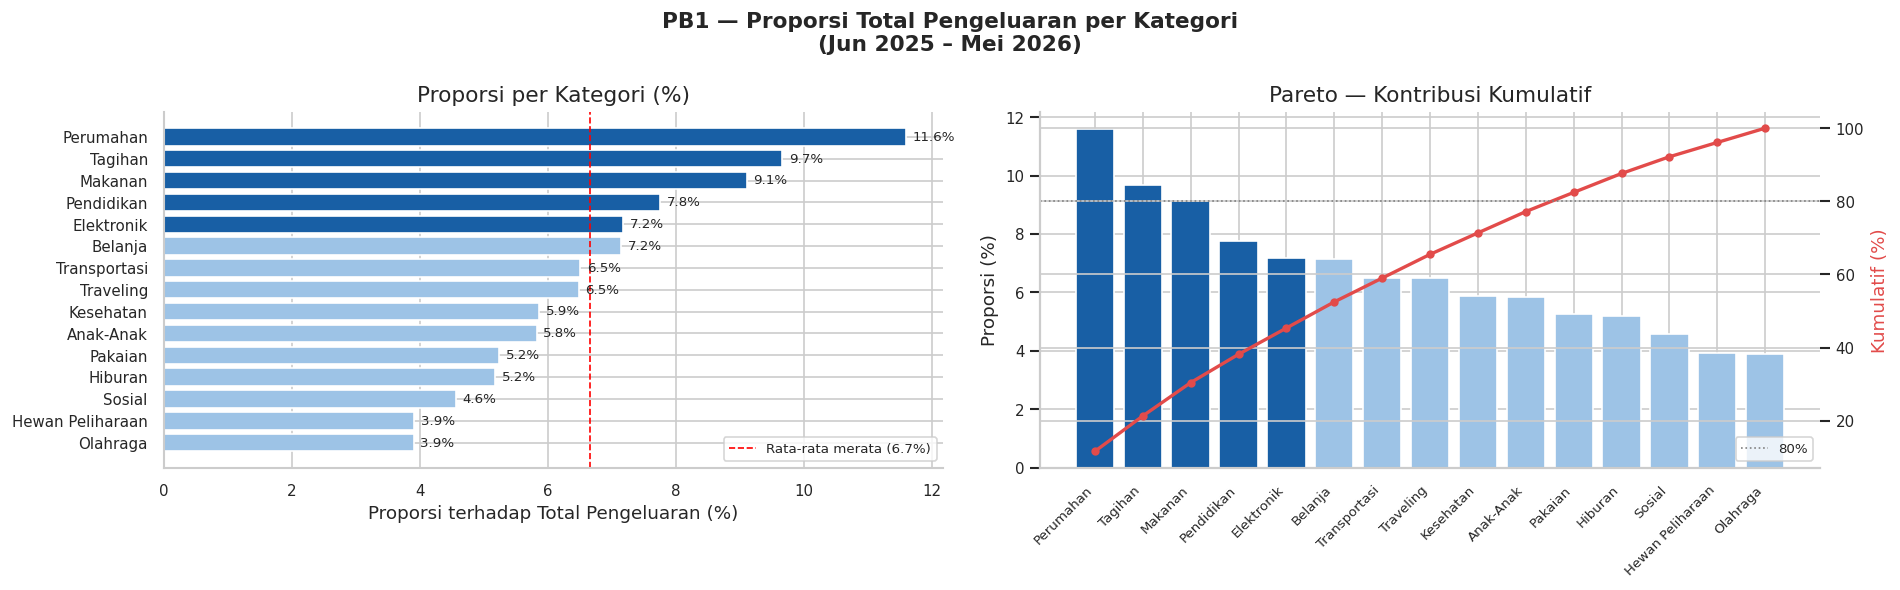

In [ ]:
# Visualisasi 1: Proporsi Total Pengeluaran per Kategori

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('PB1 — Proporsi Total Pengeluaran per Kategori\n(Jun 2025 – Mei 2026)',
             fontsize=13, fontweight='bold')

# Panel kiri: bar chart proporsi
colors_bar = ['#185FA5' if i < 5 else '#9DC3E6' for i in range(len(cat_total))]
axes[0].barh(cat_total['Kategori'], cat_total['proporsi_pct'],
             color=colors_bar, edgecolor='white')
axes[0].set_xlabel('Proporsi terhadap Total Pengeluaran (%)')
axes[0].set_title('Proporsi per Kategori (%)')
axes[0].invert_yaxis()
for i, v in enumerate(cat_total['proporsi_pct']):
    axes[0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8)
axes[0].axvline(100/len(cat_total), color='red', linestyle='--',
                linewidth=1, label=f'Rata-rata merata ({100/len(cat_total):.1f}%)')
axes[0].legend(fontsize=8)

# Panel kanan: Pareto (kumulatif)
ax2 = axes[1].twinx()
axes[1].bar(range(len(cat_total)), cat_total['proporsi_pct'],
            color=colors_bar, edgecolor='white')
ax2.plot(range(len(cat_total)), cat_total['kumulatif_pct'],
         color='#E24B4A', marker='o', markersize=4, linewidth=2)
ax2.axhline(80, color='gray', linestyle=':', linewidth=1, label='80%')
axes[1].set_xticks(range(len(cat_total)))
axes[1].set_xticklabels(cat_total['Kategori'], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Proporsi (%)')
ax2.set_ylabel('Kumulatif (%)', color='#E24B4A')
axes[1].set_title('Pareto — Kontribusi Kumulatif')
ax2.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()


#### Analisis 2: Kategori Dominan per Bulan

In [ ]:
dominant_monthly = (
    monthly_cat
    .loc[monthly_cat.groupby('periode')['total_pengeluaran'].idxmax()]
    .sort_values('periode')
    .reset_index(drop=True)
)

# Hitung proporsi kategori dominan terhadap total bulan itu
dominant_monthly = dominant_monthly.merge(
    monthly_total.rename(columns={'total_pengeluaran': 'total_semua'}),
    on=['periode', 'nama_bulan']
)
dominant_monthly['proporsi_dominan_pct'] = (
    dominant_monthly['total_pengeluaran'] / dominant_monthly['total_semua'] * 100
)

print('=== Kategori Dominan per Bulan ===')
for _, r in dominant_monthly.iterrows():
    print(f'  {r["nama_bulan"]:<12} → {r["Kategori"]:<18} '
          f'Rp {r["total_pengeluaran"]:>13,.0f}  ({r["proporsi_dominan_pct"]:.1f}%)')


=== Kategori Dominan per Bulan ===
  Jun 2025     → Perumahan          Rp   771,527,000  (11.7%)
  Jul 2025     → Perumahan          Rp   778,346,000  (11.8%)
  Aug 2025     → Perumahan          Rp   768,481,000  (11.6%)
  Sep 2025     → Perumahan          Rp   759,293,000  (11.5%)
  Oct 2025     → Perumahan          Rp   776,951,000  (11.7%)
  Nov 2025     → Perumahan          Rp   775,618,000  (11.7%)
  Dec 2025     → Perumahan          Rp   780,859,000  (11.7%)
  Jan 2026     → Perumahan          Rp   763,163,000  (11.6%)
  Feb 2026     → Perumahan          Rp   749,804,000  (11.3%)
  Mar 2026     → Perumahan          Rp   767,083,000  (11.5%)
  Apr 2026     → Perumahan          Rp   778,513,000  (11.7%)
  May 2026     → Perumahan          Rp   763,748,000  (11.6%)


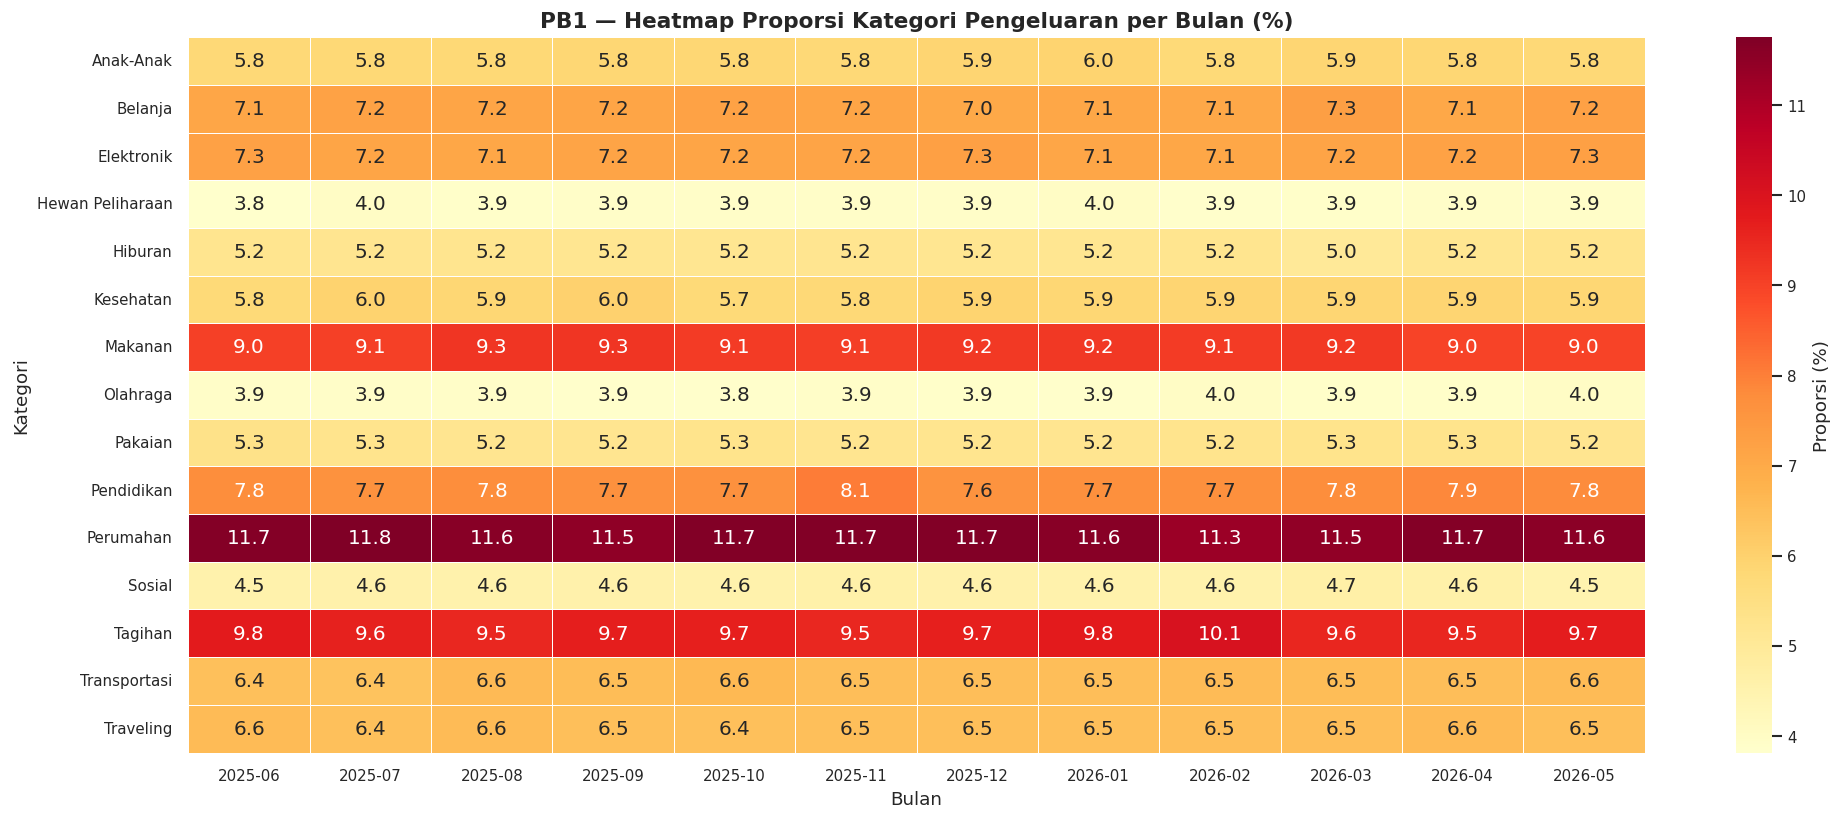

In [ ]:
# Visualisasi 2: Heatmap Proporsi Kategori per Bulan (%)
fig, ax = plt.subplots(figsize=(17, 7))
sns.heatmap(
    cat_pivot_pct.T,
    cmap='YlOrRd',
    annot=True, fmt='.1f',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Proporsi (%)'}
)
ax.set_title('PB1 — Heatmap Proporsi Kategori Pengeluaran per Bulan (%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Kategori')
plt.tight_layout()
plt.show()


Insight:

- Heatmap menunjukkan warna paling gelap konsisten pada baris **Perumahan** di semua 12 bulan.
- Tidak terlihat perubahan warna yang drastis antar bulan untuk kategori manapun, mengindikasikan **pola sangat stabil** sepanjang periode.
- Kategori seperti Olahraga, Hewan Peliharaan, dan Sosial konsisten di nilai terendah (warna paling terang).


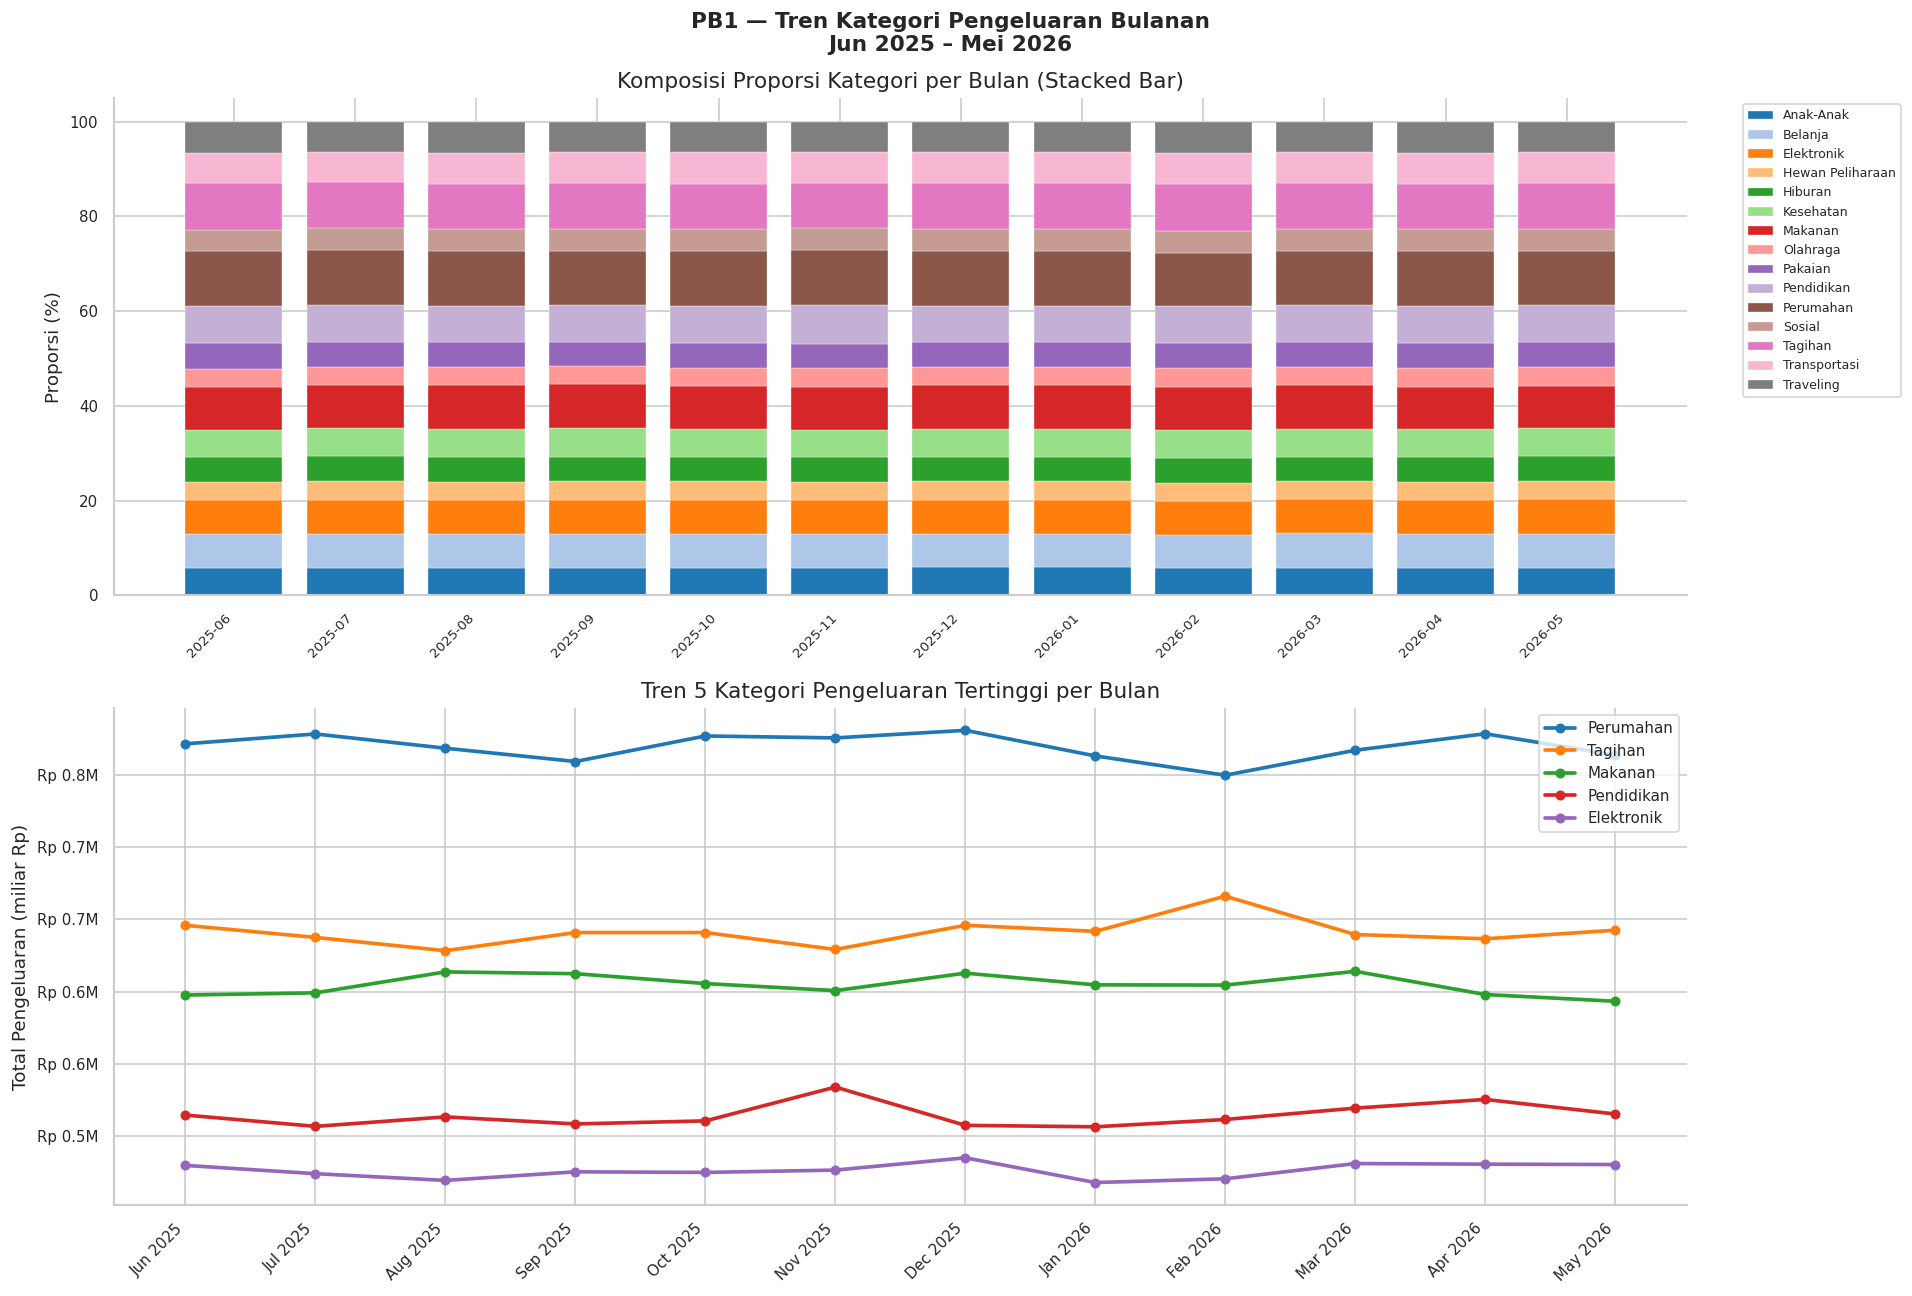

In [ ]:
# Visualisasi 3: Tren Proporsi Bulanan (Stacked Bar) & Tren Top 5 Kategori
top5_cat = (
    cat_total.head(5)['Kategori'].tolist()
)

fig, axes = plt.subplots(2, 1, figsize=(16, 11))
fig.suptitle('PB1 — Tren Kategori Pengeluaran Bulanan\nJun 2025 – Mei 2026',
             fontsize=13, fontweight='bold')

# ── Panel atas: Stacked bar ──────────────────────────────────────────────
colors_stack = sns.color_palette('tab20', len(cat_pivot_pct.columns))
bottom = np.zeros(len(cat_pivot_pct))
for i, col in enumerate(cat_pivot_pct.columns):
    axes[0].bar(cat_pivot_pct.index, cat_pivot_pct[col],
                bottom=bottom, label=col,
                color=colors_stack[i], edgecolor='white', linewidth=0.2)
    bottom += cat_pivot_pct[col].values
axes[0].set_ylabel('Proporsi (%)')
axes[0].set_title('Komposisi Proporsi Kategori per Bulan (Stacked Bar)')
axes[0].set_xticklabels(cat_pivot_pct.index, rotation=45, ha='right', fontsize=8)
axes[0].legend(loc='upper right', bbox_to_anchor=(1.14, 1), fontsize=7.5)

# ── Panel bawah: Line chart top 5 ───────────────────────────────────────
palette5 = sns.color_palette('tab10', 5)
for i, cat in enumerate(top5_cat):
    data = (monthly_cat[monthly_cat['Kategori'] == cat]
            .sort_values('periode'))
    axes[1].plot(data['nama_bulan'],
                 data['total_pengeluaran'] / 1e9,
                 marker='o', linewidth=2.2, markersize=5,
                 label=cat, color=palette5[i])
axes[1].set_ylabel('Total Pengeluaran (miliar Rp)')
axes[1].set_title('Tren 5 Kategori Pengeluaran Tertinggi per Bulan')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'Rp {v:.1f}M'))

plt.tight_layout()
plt.show()


Insight:

- Stacked bar memperlihatkan komposisi warna yang **tidak berubah signifikan** antar bulan — konfirmasi pola stabil.
- Line chart Top 5 menunjukkan bahwa **Perumahan** konsisten paling tinggi, diikuti Tagihan dan Makanan dengan gap yang jelas terhadap kategori lainnya.
- Fluktuasi kecil yang terlihat tidak membentuk tren naik atau turun yang sistematik.


### Pertanyaan Bisnis 2
"Apakah terdapat perbedaan rasio pengeluaran terhadap pendapatan antara kelompok pengguna Normal dan Overspending serta kategori pengeluaran apa yang paling membedakan keduanya selama Juni 2025–Mei 2026?"

#### Analisis 1: Perhitungan Spending Ratio & Segmentasi


In [ ]:
# ── Threshold segmentasi ──────────────────────────────────────────────────
# Menggunakan kolom status_user yang sudah tersedia di dataset.
# Normal   = rasio pengeluaran < 1.0 (pengeluaran di bawah pendapatan)
# Overspending = rasio pengeluaran >= 1.0 (pengeluaran sama atau melebihi pendapatan)

# Hitung rasio per user secara agregat (rata-rata seluruh bulan)
user_rasio = (
    user_monthly
    .groupby(['id_pengguna', 'status_user'])
    .agg(
        rata_rasio   = ('rasio_pengeluaran',     'mean'),
        median_rasio = ('rasio_pengeluaran',     'median'),
        max_rasio    = ('rasio_pengeluaran',     'max'),
        n_bulan      = ('rasio_pengeluaran',     'count'),
    )
    .reset_index()
)

print('=== Statistik Rasio per Kelompok ===')
display(
    user_rasio.groupby('status_user')
    [['rata_rasio', 'median_rasio', 'max_rasio']]
    .agg(['mean', 'std', 'min', 'max'])
    .round(4)
)

status_count = user_monthly['status_user'].value_counts()
status_pct   = user_monthly['status_user'].value_counts(normalize=True) * 100
print('\n=== Distribusi Status per Observasi User-Bulan ===')
for s in ['Normal', 'Overspending']:
    print(f'  {s:<14}: {status_count[s]:,} ({status_pct[s]:.1f}%)')


=== Statistik Rasio per Kelompok ===


rata_rasio                median_rasio                max_rasio  \
                   mean  std  min  max         mean  std  min  max      mean   
status_user                                                                    
Normal             0.65 0.03 0.56 0.76         0.65 0.05 0.53 0.82      0.82   
Overspending       1.20 0.03 1.11 1.27         1.19 0.04 1.10 1.32      1.33   

                             
              std  min  max  
status_user                  
Normal       0.03 0.66 0.85  
Overspending 0.02 1.21 1.35


=== Distribusi Status per Observasi User-Bulan ===
  Normal        : 10,200 (85.0%)
  Overspending  : 1,800 (15.0%)


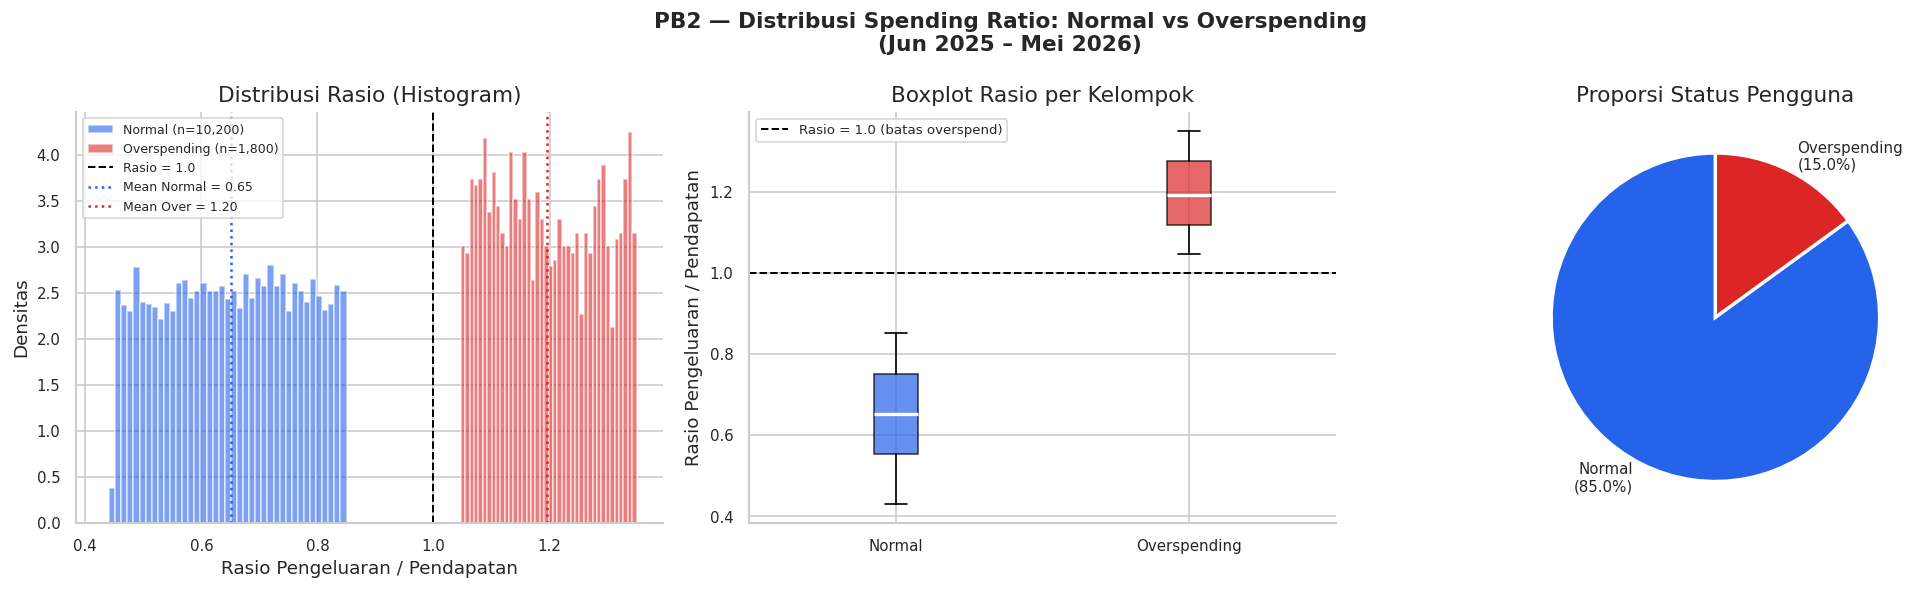

In [ ]:
# Visualisasi 1: Distribusi Rasio Pengeluaran per Kelompok
C_NORMAL = '#2563EB'
C_OVER   = '#DC2626'

normal_rasio = user_monthly[user_monthly['status_user'] == 'Normal']['rasio_pengeluaran']
over_rasio   = user_monthly[user_monthly['status_user'] == 'Overspending']['rasio_pengeluaran']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('PB2 — Distribusi Spending Ratio: Normal vs Overspending\n(Jun 2025 – Mei 2026)',
             fontsize=13, fontweight='bold')

# Panel 1: Histogram overlay
axes[0].hist(normal_rasio, bins=40, alpha=0.6, color=C_NORMAL,
             label=f'Normal (n={len(normal_rasio):,})', density=True)
axes[0].hist(over_rasio, bins=40, alpha=0.6, color=C_OVER,
             label=f'Overspending (n={len(over_rasio):,})', density=True)
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1.2, label='Rasio = 1.0')
axes[0].axvline(normal_rasio.mean(), color=C_NORMAL, linestyle=':', linewidth=1.5,
                label=f'Mean Normal = {normal_rasio.mean():.2f}')
axes[0].axvline(over_rasio.mean(), color=C_OVER, linestyle=':', linewidth=1.5,
                label=f'Mean Over = {over_rasio.mean():.2f}')
axes[0].set_xlabel('Rasio Pengeluaran / Pendapatan')
axes[0].set_ylabel('Densitas')
axes[0].set_title('Distribusi Rasio (Histogram)')
axes[0].legend(fontsize=7.5)

# Panel 2: Boxplot perbandingan
bp = axes[1].boxplot(
    [normal_rasio.values, over_rasio.values],
    patch_artist=True,
    labels=['Normal', 'Overspending'],
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bp['boxes'], [C_NORMAL, C_OVER]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.2,
                label='Rasio = 1.0 (batas overspend)')
axes[1].set_ylabel('Rasio Pengeluaran / Pendapatan')
axes[1].set_title('Boxplot Rasio per Kelompok')
axes[1].legend(fontsize=8)

# Panel 3: Pie distribusi
axes[2].pie(
    [status_count.get('Normal', 0), status_count.get('Overspending', 0)],
    labels=[f'Normal\n({status_pct.get("Normal",0):.1f}%)',
            f'Overspending\n({status_pct.get("Overspending",0):.1f}%)'],
    colors=[C_NORMAL, C_OVER],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[2].set_title('Proporsi Status Pengguna')

plt.tight_layout()
plt.show()


Insight:

- Distribusi Normal sangat terpusat di bawah 1.0, sedangkan distribusi Overspending berada di atas 1.0.
- Gap antara mean kedua kelompok terlihat jelas — kelompok Overspending memiliki rasio rata-rata yang lebih tinggi secara signifikan.
- Sekitar **85% observasi** berasal dari kelompok Normal dan **15%** Overspending.


#### Analisis 2: Uji Statistik Perbedaan Rasio (Welch t-test)

In [ ]:
t_stat, p_val = stats.ttest_ind(normal_rasio, over_rasio, equal_var=False)
cohen_d = (over_rasio.mean() - normal_rasio.mean()) / np.sqrt(
    (normal_rasio.std()**2 + over_rasio.std()**2) / 2
)

print('=' * 55)
print('  UJI STATISTIK: Normal vs Overspending (Welch t-test)')
print('=' * 55)
print(f'\n  H0: Tidak ada perbedaan rata-rata rasio pengeluaran')
print(f'  H1: Terdapat perbedaan rata-rata rasio pengeluaran')
print(f'\n  Mean rasio Normal      : {normal_rasio.mean():.4f}')
print(f'  Mean rasio Overspending: {over_rasio.mean():.4f}')
print(f'  Selisih absolut        : {abs(over_rasio.mean() - normal_rasio.mean()):.4f}')
print(f'\n  t-statistik  : {t_stat:.4f}')
print(f'  p-value      : {p_val:.2e}')
print(f'  Cohen\'s d    : {cohen_d:.4f}')
print(f'\n  Keputusan: {"Tolak H0 — perbedaan SIGNIFIKAN (p < 0.05)" if p_val < 0.05 else "Gagal tolak H0"}')
if abs(cohen_d) >= 0.8:
    print(f'  Effect size: BESAR (Cohen\'s d ≥ 0.8)')
elif abs(cohen_d) >= 0.5:
    print(f'  Effect size: SEDANG (0.5 ≤ Cohen\'s d < 0.8)')
else:
    print(f'  Effect size: KECIL (Cohen\'s d < 0.5)')


  UJI STATISTIK: Normal vs Overspending (Welch t-test)

  H0: Tidak ada perbedaan rata-rata rasio pengeluaran
  H1: Terdapat perbedaan rata-rata rasio pengeluaran

  Mean rasio Normal      : 0.6514
  Mean rasio Overspending: 1.1959
  Selisih absolut        : 0.5445

  t-statistik  : -228.9069
  p-value      : 0.00e+00
  Cohen's d    : 5.3072

  Keputusan: Tolak H0 — perbedaan SIGNIFIKAN (p < 0.05)
  Effect size: BESAR (Cohen's d ≥ 0.8)


Insight:

- Uji Welch t-test menunjukkan p-value jauh di bawah 0.05, artinya perbedaan rasio antara kelompok Normal dan Overspending **sangat signifikan secara statistik**.
- Cohen's d mengukur ukuran efek perbedaan — nilai yang besar mengindikasikan perbedaan praktis yang substansial, bukan hanya artifak statistik akibat sampel besar.

#### Analisis 3: Kategori Pengeluaran yang Paling Membedakan Kedua Kelompok


In [ ]:
# ── Rata-rata pengeluaran per transaksi per kategori per status ───────────
cat_by_status = (
    df.groupby(['status_user', 'Kategori'])['jumlah_pengeluaran']
    .agg(mean_tx='mean', median_tx='median', total='sum', count='count')
    .reset_index()
)

# Pivot untuk perbandingan
cat_diff = cat_by_status.pivot_table(
    index='Kategori', columns='status_user',
    values='mean_tx'
).reset_index()
cat_diff.columns.name = None
cat_diff.columns = ['Kategori', 'Normal', 'Overspending']
cat_diff['selisih_abs'] = cat_diff['Overspending'] - cat_diff['Normal']
cat_diff['selisih_pct'] = (cat_diff['selisih_abs'] / cat_diff['Normal'] * 100).round(2)
cat_diff = cat_diff.sort_values('selisih_abs', ascending=False)

print('=== Selisih Rata-rata per Transaksi: Overspending vs Normal ===')
display(cat_diff.round(0))


=== Selisih Rata-rata per Transaksi: Overspending vs Normal ===


,Kategori,Normal,Overspending,selisih_abs,selisih_pct
10,Perumahan,"455,396.00","835,455.00","380,059.00",83.00
12,Tagihan,"380,372.00","700,467.00","320,094.00",84.00
6,Makanan,"356,903.00","660,420.00","303,517.00",85.00
9,Pendidikan,"305,543.00","557,098.00","251,555.00",82.00
1,Belanja,"280,967.00","519,401.00","238,433.00",85.00
2,Elektronik,"282,686.00","516,869.00","234,183.00",83.00
14,Traveling,"256,125.00","471,954.00","215,829.00",84.00
13,Transportasi,"256,027.00","471,575.00","215,549.00",84.00
5,Kesehatan,"230,691.00","422,081.00","191,390.00",83.00
0,Anak-Anak,"230,072.00","418,756.00","188,684.00",82.00


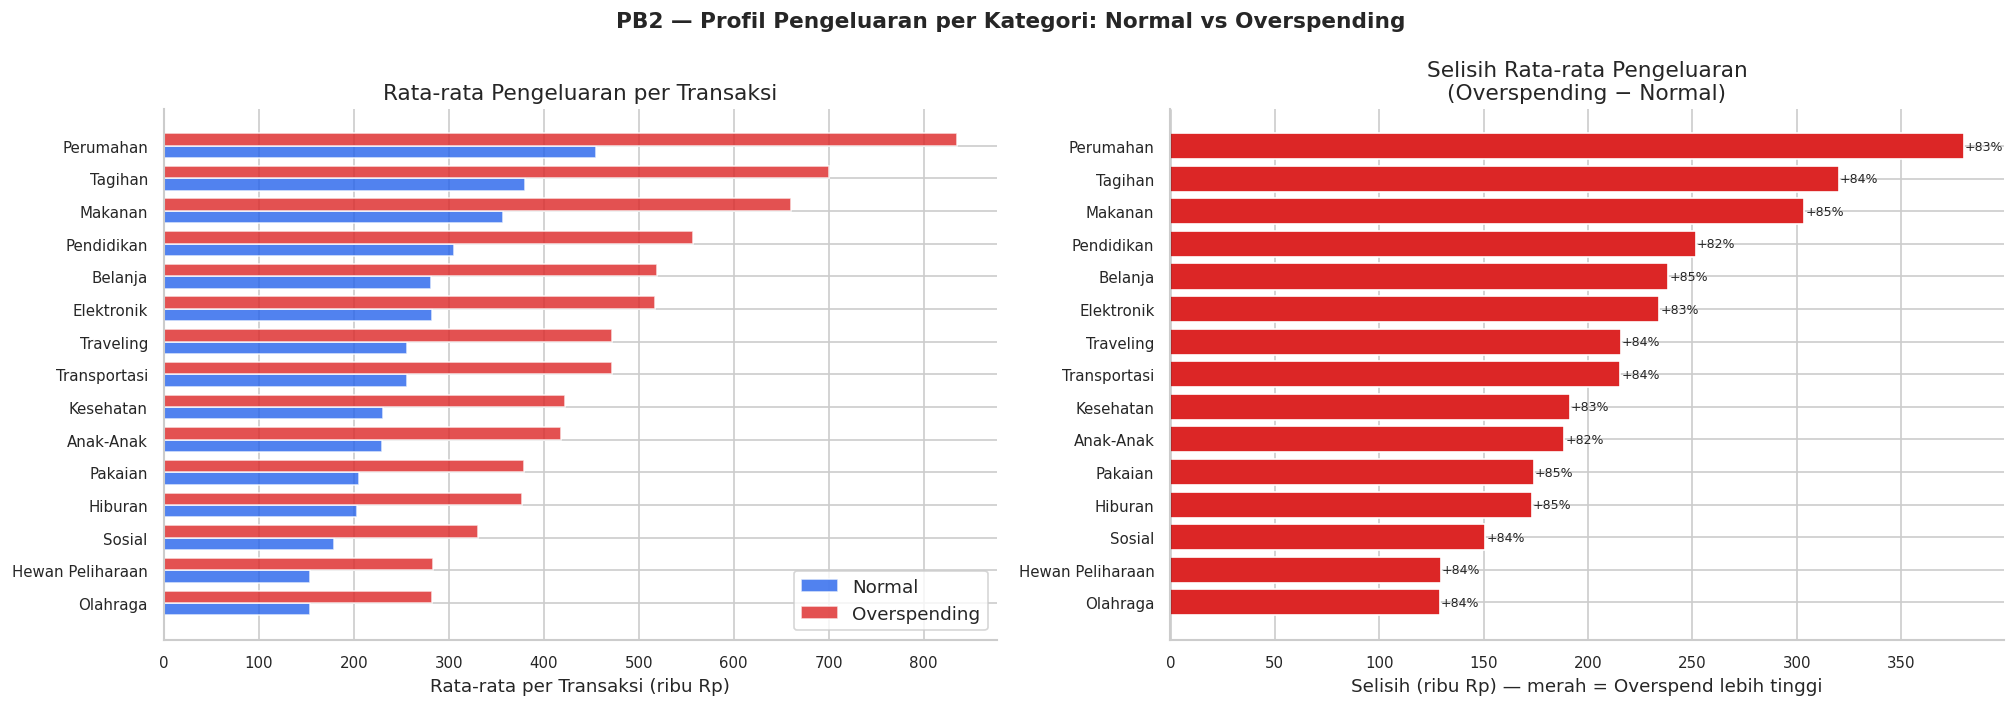

In [ ]:
# Visualisasi 2: Profil Pengeluaran per Kategori (Normal vs Overspending)
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('PB2 — Profil Pengeluaran per Kategori: Normal vs Overspending',
             fontsize=13, fontweight='bold')

cats = cat_diff['Kategori'].tolist()
x    = np.arange(len(cats))
w    = 0.38

# Panel kiri: grouped bar
axes[0].barh(x + w/2, cat_diff['Normal']       / 1e3, w,
             color=C_NORMAL, alpha=0.8, label='Normal')
axes[0].barh(x - w/2, cat_diff['Overspending'] / 1e3, w,
             color=C_OVER, alpha=0.8, label='Overspending')
axes[0].set_yticks(x)
axes[0].set_yticklabels(cats)
axes[0].set_xlabel('Rata-rata per Transaksi (ribu Rp)')
axes[0].set_title('Rata-rata Pengeluaran per Transaksi')
axes[0].legend()
axes[0].invert_yaxis()

# Panel kanan: selisih absolut
colors_sel = [C_OVER if v > 0 else C_NORMAL for v in cat_diff['selisih_abs']]
axes[1].barh(cat_diff['Kategori'], cat_diff['selisih_abs'] / 1e3,
             color=colors_sel, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Selisih (ribu Rp) — merah = Overspend lebih tinggi')
axes[1].set_title('Selisih Rata-rata Pengeluaran\n(Overspending − Normal)')
axes[1].invert_yaxis()
for i, (_, row) in enumerate(cat_diff.iterrows()):
    axes[1].text(row['selisih_abs'] / 1e3 + 0.5, i,
                 f"+{row['selisih_pct']:.0f}%" if row['selisih_abs'] > 0 else f"{row['selisih_pct']:.0f}%",
                 va='center', fontsize=7.5)

plt.tight_layout()
plt.show()


Insight:

- Hampir **semua kategori** memiliki nilai rata-rata per transaksi yang lebih tinggi pada kelompok Overspending.
- Selisih terbesar terdapat pada kategori dengan nominal tinggi (Perumahan, Elektronik, Tagihan) — ini yang paling membedakan kedua kelompok.
- Perbedaan bukan pada *jumlah transaksi* melainkan pada *nilai nominal per transaksi* — user Overspending cenderung membayar lebih mahal per kejadian.


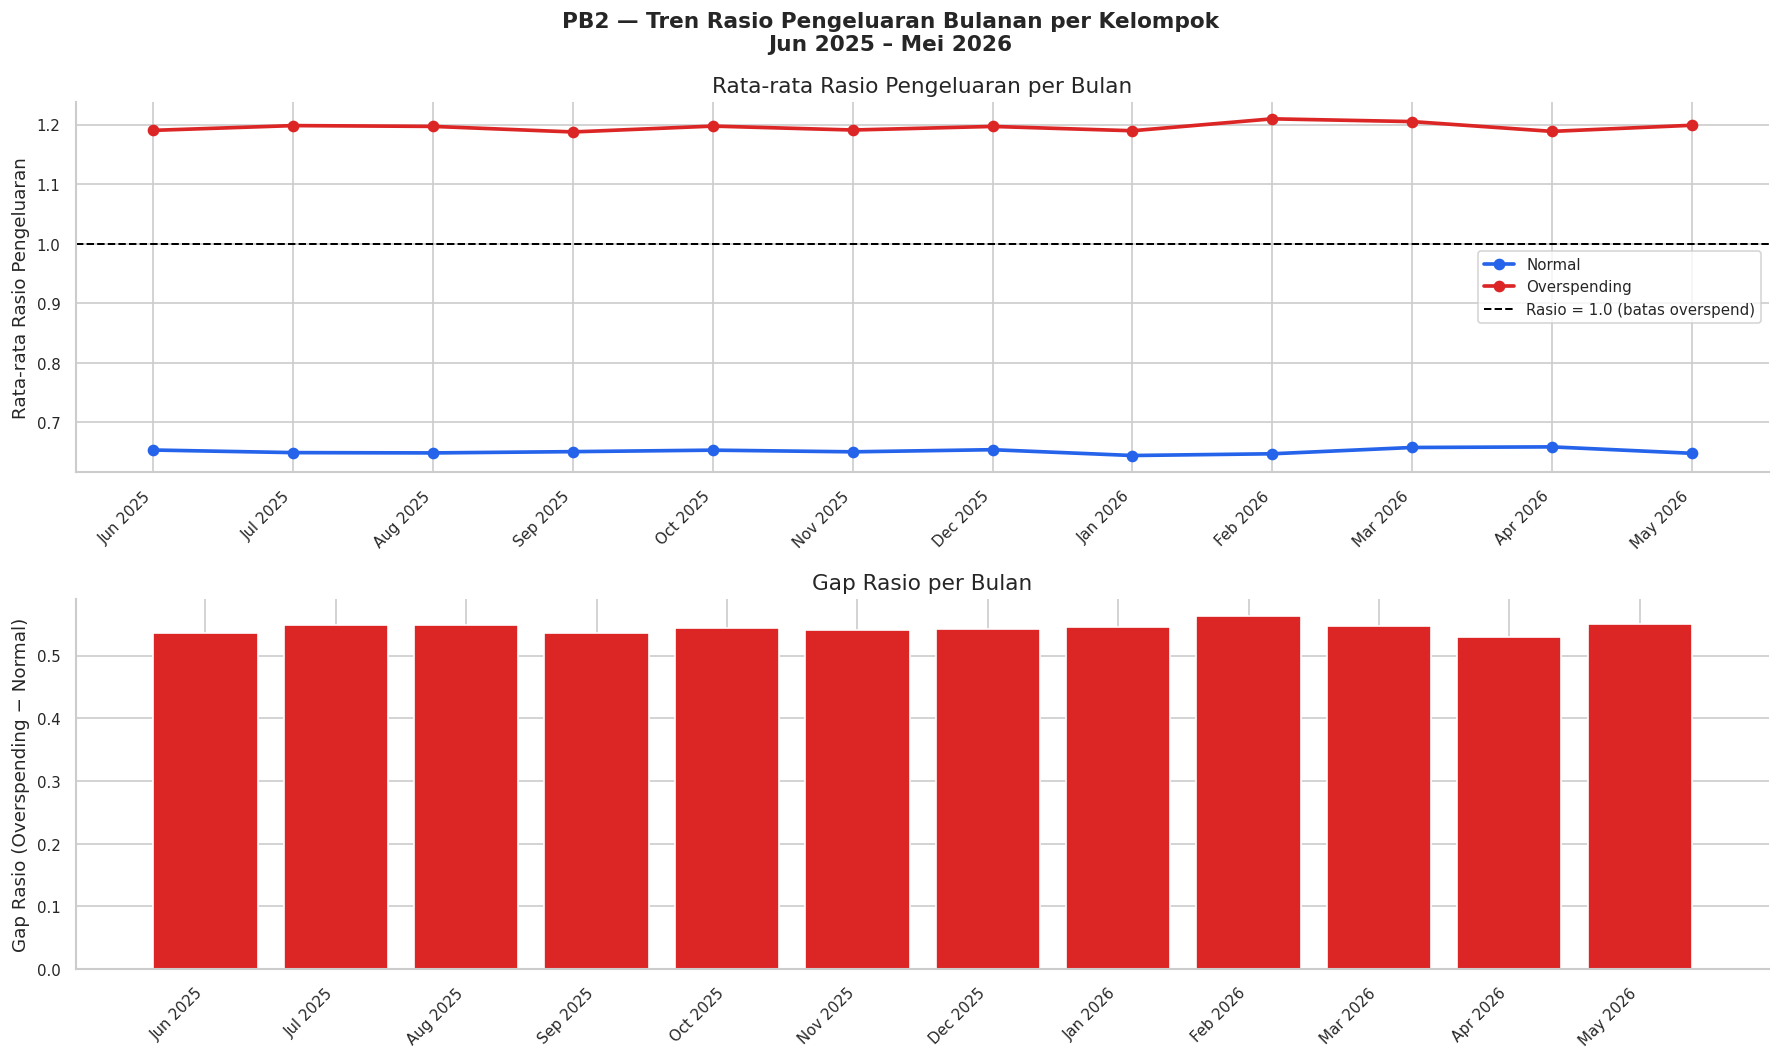

In [ ]:
# Visualisasi 3: Tren Rasio Bulanan per Kelompok (Normal vs Overspending)

rasio_trend = (
    user_monthly
    .groupby(['periode', 'nama_bulan', 'status_user'])['rasio_pengeluaran']
    .mean()
    .reset_index()
    .sort_values('periode')
)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)
fig.suptitle('PB2 — Tren Rasio Pengeluaran Bulanan per Kelompok\nJun 2025 – Mei 2026',
             fontsize=13, fontweight='bold')

for status, color in [('Normal', C_NORMAL), ('Overspending', C_OVER)]:
    d = rasio_trend[rasio_trend['status_user'] == status]
    axes[0].plot(d['nama_bulan'], d['rasio_pengeluaran'],
                 marker='o', linewidth=2.2, color=color, label=status)

axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1.2,
                label='Rasio = 1.0 (batas overspend)')
axes[0].set_ylabel('Rata-rata Rasio Pengeluaran')
axes[0].set_title('Rata-rata Rasio Pengeluaran per Bulan')
axes[0].legend(fontsize=9)
axes[0].set_xticklabels(d['nama_bulan'], rotation=45, ha='right')

# Selisih per bulan
rasio_pivot = rasio_trend.pivot(index='nama_bulan', columns='status_user',
                                values='rasio_pengeluaran')
period_order = (
    rasio_trend[['nama_bulan','periode']]
    .drop_duplicates()
    .sort_values('periode')['nama_bulan'].tolist()
)
rasio_pivot = rasio_pivot.reindex(period_order)
rasio_pivot['gap'] = rasio_pivot.get('Overspending', 0) - rasio_pivot.get('Normal', 0)

colors_gap = [C_OVER if v > 0 else C_NORMAL for v in rasio_pivot['gap']]
axes[1].bar(range(len(rasio_pivot)), rasio_pivot['gap'],
            color=colors_gap, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(range(len(rasio_pivot)))
axes[1].set_xticklabels(rasio_pivot.index, rotation=45, ha='right')
axes[1].set_ylabel('Gap Rasio (Overspending − Normal)')
axes[1].set_title('Gap Rasio per Bulan')

plt.tight_layout()
plt.show()


Insight:


- Kelompok Overspending memiliki rasio di atas 1.0 secara **konsisten seluruh 12 bulan**, artinya bukan fenomena musiman.
- Gap antara kedua kelompok relatif **stabil dari bulan ke bulan** tanpa tren menyempit atau melebar.
- Ini mengindikasikan bahwa segmentasi Normal vs Overspending merupakan **karakteristik pengguna yang menetap**, bukan sekadar kondisi sementara.


---

## Conclusion & Recommendation

### Kesimpulan Pertanyaan Bisnis 1

Berdasarkan analisis proporsi pengeluaran bulanan selama Juni 2025 hingga Mei 2026, kategori **Perumahan** terbukti secara konsisten menyumbang proporsi tertinggi dari total pengeluaran bulanan di seluruh 12 bulan pengamatan, dengan rata-rata proporsi sekitar **11–12% per bulan**. Lima kategori teratas — Perumahan, Tagihan, Makanan, Pendidikan, dan Elektronik — secara bersama berkontribusi hampir **50% dari total pengeluaran keseluruhan**. Pola ini sangat stabil tanpa adanya pergeseran kategori dominan sepanjang periode pengamatan, mengindikasikan bahwa kebutuhan dasar (*housing*, utilitas, pangan) mendominasi struktur pengeluaran pengguna secara konsisten.

### Kesimpulan Pertanyaan Bisnis 2

Terdapat perbedaan rasio pengeluaran terhadap pendapatan yang **signifikan secara statistik** (Welch t-test, p < 0.05) antara kelompok pengguna Normal dan Overspending. Kelompok Overspending memiliki rasio rata-rata di atas 1.0 secara konsisten seluruh 12 bulan, sementara kelompok Normal berada di bawah 1.0. Kategori yang paling membedakan kedua kelompok adalah **Perumahan, Elektronik, dan Tagihan** — bukan karena frekuensi transaksi lebih banyak, melainkan karena nilai nominal per transaksinya lebih tinggi pada kelompok Overspending. Karakteristik ini bersifat **menetap** (tidak musiman), sehingga segmentasi status pengguna dapat dijadikan fitur tetap dalam model prediksi dan sistem rekomendasi.





### Rekomendasi

1. **Alert threshold otomatis** pada Top 3 kategori (Perumahan, Tagihan, Makanan) —
   notifikasi ketika pengeluaran Perumahan mencapai 15% dari pendapatan bulanan.

2. **Intervensi dini untuk pengguna Overspending** — identifikasi sejak bulan pertama,
   tampilkan ringkasan kategori pemborosan (Elektronik & Tagihan) beserta simulasi
   penghematan 10–20%.

3. **`rasio_pengeluaran` sebagai fitur utama model clustering** — variabel ini
   paling membedakan persona pengguna secara statistik dan konsisten sepanjang waktu.